# W07 – Profiling Report | Team A | Szenario A: VetKliniken-Verbund

Dieses Notebook erstellt alle Artefakte für Meilenstein W7:
- Profiling-Reports je Quelldatei (Markdown)
- Data Dictionary (Markdown)
- Fehlerliste (Markdown)

## 0 · Abhängigkeiten installieren

In [1]:
!pip install -q duckdb lxml ydata-profiling pandas openpyxl

## 1 · Repository klonen

In [2]:
import os

REPO_URL = "https://git.x-breed.de/magruene/fallstudie_datenmanagement_master.git"
REPO_DIR = "fallstudie_datenmanagement_master"

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL}
else:
    print("Repo bereits vorhanden – überspringe Clone.")

# Basis-Pfad zu den Verbund-Quelldateien
DATA_DIR = os.path.join(REPO_DIR, "verbund")
print("Dateien im verbund/-Ordner:")
for f in sorted(os.listdir(DATA_DIR)):
    print(" ", f)

Repo bereits vorhanden – überspringe Clone.
Dateien im verbund/-Ordner:
  beispiel_embeddings.py
  beispiel_llm_match.py
  gold_cluster.csv
  praxis_bergblick_export.xml
  praxis_juckstadt_behandlungen.csv
  praxis_juckstadt_kunden.csv
  praxis_schmidt_behandlungen.json
  praxis_schmidt_kunden.csv
  praxis_waldrand_behandlungen.csv
  praxis_waldrand_kunden.csv
  zielschema.sql


## 2 · Imports & Hilfsfunktionen

In [3]:
import pandas as pd
import duckdb
import json
import os
from lxml import etree
from pathlib import Path
from datetime import datetime

# Ausgabe-Verzeichnis für Markdown-Reports
OUT_DIR = Path("docs/w7_profiling")
OUT_DIR.mkdir(parents=True, exist_ok=True)

def null_pct(series: pd.Series) -> str:
    """Anteil fehlender Werte als formatierter String."""
    pct = series.isna().mean() * 100
    return f"{pct:.1f}%"

def distinct_count(series: pd.Series) -> int:
    return series.nunique(dropna=False)

def example_val(series: pd.Series) -> str:
    """Erstes nicht-leeres Beispiel."""
    vals = series.dropna()
    return str(vals.iloc[0]) if len(vals) > 0 else "–"

def guess_type(series: pd.Series) -> str:
    """Einfache Typ-Vermutung auf Basis von Pandas."""
    if pd.api.types.is_integer_dtype(series):
        return "INTEGER"
    if pd.api.types.is_float_dtype(series):
        return "FLOAT"
    # Datum-Check
    sample = series.dropna().head(20).astype(str)
    date_hits = sample.str.match(
        r"\d{4}-\d{2}-\d{2}|\d{2}/\d{2}/\d{4}|\d{2}\.\d{2}\.\d{4}"
    ).sum()
    if date_hits >= len(sample) * 0.8:
        return "DATE"
    return "VARCHAR"

def df_to_column_table(df: pd.DataFrame) -> str:
    """Erstellt die Markdown-Spalten-Tabelle für einen DataFrame."""
    lines = [
        "| Spalte | Typ-Vermutung | Beispiel | Distinct | Null% | Bemerkung |",
        "|---|---|---|---:|---:|---|",
    ]
    for col in df.columns:
        typ = guess_type(df[col])
        ex = example_val(df[col]).replace("|", "\\|")
        d = distinct_count(df[col])
        n = null_pct(df[col])
        lines.append(f"| `{col}` | {typ} | {ex} | {d} | {n} |  |")
    return "\n".join(lines)

def write_report(filename: str, content: str):
    path = OUT_DIR / filename
    path.write_text(content, encoding="utf-8")
    print(f"  ✓ {path}")

print("Hilfsfunktionen geladen.")

Hilfsfunktionen geladen.


# **3 · Profiling: Praxis Juckstadt**


**Ziel des Profilings:** Dateistruktur verstehen, Spaltenprofile erstellen, Fehlwerte und Formatprobleme erkennen, Verteilungen sichtbar machen und Integrationsrisiken für das spätere Staging/Matching dokumentieren.

### **Quelldateien laden**

**Anmerkung:** Beide Juckstadt-Dateien sind Semikolon-getrennte CSV-Dateien. Die Zelle nutzt zuerst die Dateien aus dem Repository.

In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


def first_existing_path(candidates):
    """
    Gibt den ersten existierenden Pfad aus einer Kandidatenliste zurück.
    Priorität hat der Pfad aus dem geklonten Repository.
    """
    for candidate in candidates:
        if candidate and Path(candidate).exists():
            return str(candidate)
    raise FileNotFoundError(
        "Keine der erwarteten Dateien wurde gefunden:\n" + "\n".join(map(str, candidates))
    )


# Dateien zuerst aus dem Repository laden, danach lokale Alternativen prüfen.
FILE_JUCK_K = first_existing_path([
    os.path.join(DATA_DIR, "praxis_juckstadt_kunden.csv"),
    "praxis_juckstadt_kunden.csv",
    "praxis_juckstadt_kunden (1).csv",
    "/mnt/data/praxis_juckstadt_kunden.csv",
    "/mnt/data/praxis_juckstadt_kunden (1).csv",
])

FILE_JUCK_B = first_existing_path([
    os.path.join(DATA_DIR, "praxis_juckstadt_behandlungen.csv"),
    "praxis_juckstadt_behandlungen.csv",
    "praxis_juckstadt_behandlungen (1).csv",
    "/mnt/data/praxis_juckstadt_behandlungen.csv",
    "/mnt/data/praxis_juckstadt_behandlungen (1).csv",
])

df_juck_k = pd.read_csv(FILE_JUCK_K, sep=";", dtype=str, encoding="utf-8")
df_juck_b = pd.read_csv(FILE_JUCK_B, sep=";", dtype=str, encoding="utf-8")

print("\nGeladene Dateien:")
print("Kunden:", FILE_JUCK_K)
print("Behandlungen:", FILE_JUCK_B)
print(f"Kunden: {len(df_juck_k)} Zeilen, {len(df_juck_k.columns)} Spalten")
print(f"Behandlungen: {len(df_juck_b)} Zeilen, {len(df_juck_b.columns)} Spalten")



Geladene Dateien:
Kunden: fallstudie_datenmanagement_master/verbund/praxis_juckstadt_kunden.csv
Behandlungen: fallstudie_datenmanagement_master/verbund/praxis_juckstadt_behandlungen.csv
Kunden: 223 Zeilen, 10 Spalten
Behandlungen: 150 Zeilen, 6 Spalten


## 3 · Profiling: praxis_juckstadt_behandlungen.csv

## 3.1.1 Struktur

In [5]:
# Schritt 1: Struktur der Kundendatei prüfen.
# Es werden nur Metadaten angezeigt, keine Daten verändert.

kunden_struktur = pd.DataFrame({
    "Merkmal": [
        "Datei",
        "Format",
        "Trennzeichen",
        "Encoding",
        "Zeilenzahl",
        "Spaltenzahl",
        "Spalten"
    ],
    "Wert": [
        "praxis_juckstadt_kunden.csv",
        "CSV",
        ";",
        "UTF-8",
        len(df_juck_k),
        len(df_juck_k.columns),
        ", ".join(df_juck_k.columns)
    ]
})

display(kunden_struktur)
display(df_juck_k.head())


,Merkmal,Wert
0,Datei,praxis_juckstadt_kunden.csv
1,Format,CSV
2,Trennzeichen,;
3,Encoding,UTF-8
4,Zeilenzahl,223
5,Spaltenzahl,10
6,Spalten,"kunden_nr, anrede, vorname, nachname, strasse,..."


,kunden_nr,anrede,vorname,nachname,strasse,plz,ort,telefon,email,angelegt_am
0,1,Herr,Thomas,Berger,Hauptstr. 12,35500,Juckstadt,06450-1234,berger@email.de,2021-05-12
1,2,Frau,Marion,Hoffmann,Kirchgasse 4,35500,Juckstadt,06450-2233,hoffmann@email.de,2024-11-29
2,3,Herr,Klaus,Weber,Am Markt 3,35500,Juckstadt,06450-9012,NaN,2024-09-29
3,4,Herr,Thomas,Neumann,Feldweg 22,35501,Oberstadt,06451-5588,neumann@email.de,2023-04-08
4,5,Herr,Markus,Lehmann,Schulstr. 21,35501,Oberstadt,06451-7890,NaN,2022-03-29


## 3.1.2 Wertebereiche

In [6]:
# Schritt 2: Typ-Vermutung, Minimum, Maximum und Distinct-Werte je Spalte.
# Die Umwandlungen in dieser Zelle dienen nur der Prüfung in temporären Variablen.
# Die Originalspalten im DataFrame bleiben unverändert.

kunden_wertebereiche_rows = []

for col in df_juck_k.columns:
    s = df_juck_k[col].dropna().astype(str).str.strip()

    if len(s) == 0:
        typ = "Unbekannt"
        minimum = None
        maximum = None
    elif s.str.fullmatch(r"\d+").mean() >= 0.9:
        typ = "Integer"
        s_num = pd.to_numeric(s, errors="coerce")
        minimum = s_num.min()
        maximum = s_num.max()
    elif s.str.fullmatch(r"\d+,\d{2}").mean() >= 0.9:
        typ = "Währung / Dezimalzahl mit Komma"
        s_num = pd.to_numeric(s.str.replace(",", ".", regex=False), errors="coerce")
        minimum = s_num.min()
        maximum = s_num.max()
    elif s.str.fullmatch(r"\d{4}-\d{2}-\d{2}").mean() >= 0.9:
        typ = "Datum"
        s_date = pd.to_datetime(s, format="%Y-%m-%d", errors="coerce")
        minimum = s_date.min()
        maximum = s_date.max()
    elif s.str.fullmatch(r"[^@\s]+@[^@\s]+\.[^@\s]+").mean() >= 0.9:
        typ = "E-Mail"
        minimum = s.min()
        maximum = s.max()
    else:
        typ = "Text"
        minimum = s.min() if len(s) > 0 else None
        maximum = s.max() if len(s) > 0 else None

    kunden_wertebereiche_rows.append({
        "Spalte": col,
        "Typ-Vermutung": typ,
        "Minimum": minimum,
        "Maximum": maximum,
        "Distinct-Werte": df_juck_k[col].nunique(dropna=False)
    })

kunden_wertebereiche = pd.DataFrame(kunden_wertebereiche_rows)
display(kunden_wertebereiche)


,Spalte,Typ-Vermutung,Minimum,Maximum,Distinct-Werte
0,kunden_nr,Integer,1,223,223
1,anrede,Text,Frau,Herr,2
2,vorname,Text,Andreas,Zoey,63
3,nachname,Text,Albrecht,Zimmermann,43
4,strasse,Text,Ahornweg 15,Wiesenweg 8,214
5,plz,Integer,35466,35580,8
6,ort,Text,Allendorf,Wetzlar-Niedergirmes,10
7,telefon,Text,06407-0743,06451-7890,222
8,email,E-Mail,albrecht.e@t-online.de,zimmermann.l@web.de,197
9,angelegt_am,Datum,2019-01-07 00:00:00,2026-09-21 00:00:00,215


## 3.1.3 Fehlerwerte

In [7]:
# Schritt 3: Fehlwerte und Null-Anteil je Spalte.

kunden_fehlwerte_rows = []

for col in df_juck_k.columns:
    fehlwerte = df_juck_k[col].isna().sum()
    null_anteil = df_juck_k[col].isna().mean() * 100

    kunden_fehlwerte_rows.append({
        "Spalte": col,
        "Fehlwerte": int(fehlwerte),
        "Null-Anteil in %": round(null_anteil, 2)
    })

kunden_fehlwerte = pd.DataFrame(kunden_fehlwerte_rows)
display(kunden_fehlwerte)


,Spalte,Fehlwerte,Null-Anteil in %
0,kunden_nr,0,0.00
1,anrede,0,0.00
2,vorname,0,0.00
3,nachname,0,0.00
4,strasse,0,0.00
5,plz,0,0.00
6,ort,0,0.00
7,telefon,0,0.00
8,email,21,9.42
9,angelegt_am,0,0.00


## 3.1.4 Muster

In [8]:
# Schritt 4: Musteranalyse für Datum, Telefon, E-Mail und Währung.
# Es wird nur geprüft, ob Werte zu typischen Formaten passen.

kunden_muster_rows = []

muster_definitionen = {
    "Datum YYYY-MM-DD": r"^\d{4}-\d{2}-\d{2}$",
    "Telefon lokal mit Bindestrich": r"^\d{5}-\d{4,6}$",
    "E-Mail": r"^[^@\s]+@[^@\s]+\.[^@\s]+$",
    "Währung mit deutschem Dezimalkomma": r"^\d+,\d{2}$"
}

for col in df_juck_k.columns:
    s = df_juck_k[col].dropna().astype(str).str.strip()

    for muster_name, regex in muster_definitionen.items():
        treffer = s.str.match(regex, na=False).sum()

        if len(s) > 0 and treffer > 0:
            kunden_muster_rows.append({
                "Spalte": col,
                "Erkanntes Muster": muster_name,
                "Regex": regex,
                "Treffer": int(treffer),
                "Nicht passend": int(len(s) - treffer),
                "Beispiel": s.iloc[0]
            })

kunden_muster = pd.DataFrame(kunden_muster_rows)
display(kunden_muster)


,Spalte,Erkanntes Muster,Regex,Treffer,Nicht passend,Beispiel
0,telefon,Telefon lokal mit Bindestrich,"^\d{5}-\d{4,6}$",223,0,06450-1234
1,email,E-Mail,^[^@\s]+@[^@\s]+\.[^@\s]+$,202,0,berger@email.de
2,angelegt_am,Datum YYYY-MM-DD,^\d{4}-\d{2}-\d{2}$,223,0,2021-05-12


## 3.1.5 Auffälligkeiten

In [9]:
# Schritt 5: Auffälligkeiten wie Dubletten, kaputte Formate und Ausreißer-Verdacht.
# Diese Zelle prüft nur und verändert keine Daten.

kunden_auffaelligkeiten_rows = []

kunden_auffaelligkeiten_rows.append({
    "Prüfung": "Vollständig doppelte Zeilen",
    "Auffällige Datensätze": int(df_juck_k.duplicated().sum()),
    "Hinweis": "Exakte Dubletten über alle Spalten"
})

for col in df_juck_k.columns:
    s = df_juck_k[col].dropna().astype(str).str.strip()

    if col.endswith("_nr") or col in ["kunden_nr", "beh_nr"]:
        kunden_auffaelligkeiten_rows.append({
            "Prüfung": f"Doppelte Werte in {col}",
            "Auffällige Datensätze": int(df_juck_k[col].duplicated().sum()),
            "Hinweis": "Möglicher Schlüssel / technische ID"
        })

    if "email" in col.lower():
        invalid_email = (~s.str.match(r"^[^@\s]+@[^@\s]+\.[^@\s]+$", na=False)).sum()
        kunden_auffaelligkeiten_rows.append({
            "Prüfung": f"Ungültige E-Mail-Formate in {col}",
            "Auffällige Datensätze": int(invalid_email),
            "Hinweis": "Nur Formatprüfung; fehlende Werte sind in Schritt 3 sichtbar"
        })

    if "telefon" in col.lower():
        kunden_auffaelligkeiten_rows.append({
            "Prüfung": f"Doppelte Telefonnummern in {col}",
            "Auffällige Datensätze": int(df_juck_k[col].duplicated().sum()),
            "Hinweis": "Kann fachlich erlaubt sein, aber Dubletten-Verdacht"
        })

    if "plz" in col.lower():
        invalid_plz = (~s.str.match(r"^\d{5}$", na=False)).sum()
        kunden_auffaelligkeiten_rows.append({
            "Prüfung": f"Ungültige PLZ-Formate in {col}",
            "Auffällige Datensätze": int(invalid_plz),
            "Hinweis": "Erwartet werden fünf Ziffern"
        })

    if "datum" in col.lower() or "angelegt" in col.lower():
        invalid_date = pd.to_datetime(s, format="%Y-%m-%d", errors="coerce").isna().sum()
        kunden_auffaelligkeiten_rows.append({
            "Prüfung": f"Nicht interpretierbare Datumswerte in {col}",
            "Auffällige Datensätze": int(invalid_date),
            "Hinweis": "Erwartetes Format: YYYY-MM-DD"
        })

kunden_auffaelligkeiten = pd.DataFrame(kunden_auffaelligkeiten_rows)
display(kunden_auffaelligkeiten)


,Prüfung,Auffällige Datensätze,Hinweis
0,Vollständig doppelte Zeilen,0,Exakte Dubletten über alle Spalten
1,Doppelte Werte in kunden_nr,0,Möglicher Schlüssel / technische ID
2,Ungültige PLZ-Formate in plz,0,Erwartet werden fünf Ziffern
3,Doppelte Telefonnummern in telefon,1,"Kann fachlich erlaubt sein, aber Dubletten-Ver..."
4,Ungültige E-Mail-Formate in email,0,Nur Formatprüfung; fehlende Werte sind in Schr...
5,Nicht interpretierbare Datumswerte in angelegt_am,0,Erwartetes Format: YYYY-MM-DD


## Markdown-Report

In [10]:
# ============================================================
# Markdown-Report 1: praxis_juckstadt_kunden.csv
# ============================================================

_k_col_table = df_to_column_table(df_juck_k)

_k_email_missing = int(df_juck_k["email"].isna().sum())
_k_email_invalid = int((~df_juck_k["email"].dropna().astype(str).str.match(
    r"^[^@\s]+@[^@\s]+\.[^@\s]+$", na=False
)).sum())

_k_tel_invalid = int((~df_juck_k["telefon"].dropna().astype(str).str.match(
    r"^\d{5}-\d{4,6}$", na=False
)).sum())

_k_plz_invalid = int((~df_juck_k["plz"].dropna().astype(str).str.match(
    r"^\d{5}$", na=False
)).sum())

_k_date_invalid = int(pd.to_datetime(
    df_juck_k["angelegt_am"].dropna(),
    format="%Y-%m-%d",
    errors="coerce"
).isna().sum())

_k_dupl_full = int(df_juck_k.duplicated().sum())
_k_dupl_kunden_nr = int(df_juck_k["kunden_nr"].duplicated().sum())
_k_dupl_tel = int(df_juck_k[df_juck_k["telefon"].notna()].duplicated(
    subset=["telefon"],
    keep=False
).sum())

report_juck_kunden = f"""# Profiling-Report: praxis_juckstadt_kunden.csv

_Erstellt: {datetime.today().strftime('%Y-%m-%d')}_

## Schritt 1 · Struktur

| Merkmal | Wert |
|---|---|
| Format | CSV |
| Trennzeichen | `;` |
| Encoding | UTF-8 |
| Header | ja |
| Zeilen | {len(df_juck_k)} |
| Spalten | {len(df_juck_k.columns)} |
| Spaltenname | {', '.join(df_juck_k.columns)} |

## Schritt 2 · Wertebereiche

{_k_col_table}

## Schritt 3 · Fehlwerte

| Spalte | Fehlwerte | Null% |
|---|---:|---:|
| `kunden_nr` | {int(df_juck_k['kunden_nr'].isna().sum())} | {df_juck_k['kunden_nr'].isna().mean()*100:.1f}% |
| `anrede` | {int(df_juck_k['anrede'].isna().sum())} | {df_juck_k['anrede'].isna().mean()*100:.1f}% |
| `vorname` | {int(df_juck_k['vorname'].isna().sum())} | {df_juck_k['vorname'].isna().mean()*100:.1f}% |
| `nachname` | {int(df_juck_k['nachname'].isna().sum())} | {df_juck_k['nachname'].isna().mean()*100:.1f}% |
| `strasse` | {int(df_juck_k['strasse'].isna().sum())} | {df_juck_k['strasse'].isna().mean()*100:.1f}% |
| `plz` | {int(df_juck_k['plz'].isna().sum())} | {df_juck_k['plz'].isna().mean()*100:.1f}% |
| `ort` | {int(df_juck_k['ort'].isna().sum())} | {df_juck_k['ort'].isna().mean()*100:.1f}% |
| `telefon` | {int(df_juck_k['telefon'].isna().sum())} | {df_juck_k['telefon'].isna().mean()*100:.1f}% |
| `email` | {_k_email_missing} | {_k_email_missing/len(df_juck_k)*100:.1f}% |
| `angelegt_am` | {int(df_juck_k['angelegt_am'].isna().sum())} | {df_juck_k['angelegt_am'].isna().mean()*100:.1f}% |

## Schritt 4 · Muster

| Feld | Muster | Auffälligkeiten |
|---|---|---|
| `kunden_nr` | Ganzzahl als Text gespeichert | {_k_dupl_kunden_nr} doppelte Werte |
| `anrede` | `Herr` / `Frau` | {df_juck_k['anrede'].nunique(dropna=False)} Ausprägungen |
| `plz` | 5-stellig | {_k_plz_invalid} auffällig |
| `telefon` | lokales Format mit Bindestrich, z. B. `06450-1234` | {_k_tel_invalid} auffällig |
| `email` | `xxx@xxx.xxx` | {_k_email_missing} fehlend, {_k_email_invalid} ungültig |
| `angelegt_am` | `YYYY-MM-DD` | {_k_date_invalid} nicht parsebar |

## Schritt 5 · Auffälligkeiten

| Prüfung | Befund |
|---|---:|
| Vollständig doppelte Zeilen | {_k_dupl_full} |
| Doppelte `kunden_nr` | {_k_dupl_kunden_nr} |
| Doppelte Telefonnummern | {_k_dupl_tel} |
| Fehlende E-Mail-Adressen | {_k_email_missing} |
| Ungültige E-Mail-Formate | {_k_email_invalid} |
| Ungültige PLZ-Formate | {_k_plz_invalid} |
| Nicht interpretierbare Datumswerte | {_k_date_invalid} |

**Fazit:** Die Kundendatei ist strukturell sauber einlesbar. Kritisch für spätere Integrations- und Matching-Schritte sind vor allem fehlende E-Mail-Adressen und mögliche Dubletten bei Telefonnummern. Die Spalten `kunden_nr`, `plz` und `angelegt_am` wirken anhand der Profiling-Prüfungen formal konsistent.
"""

write_report("juckstadt_kunden.md", report_juck_kunden)
print(report_juck_kunden[:800])

  ✓ docs/w7_profiling/juckstadt_kunden.md
# Profiling-Report: praxis_juckstadt_kunden.csv

_Erstellt: 2026-06-07_

## Schritt 1 · Struktur

| Merkmal | Wert |
|---|---|
| Format | CSV |
| Trennzeichen | `;` |
| Encoding | UTF-8 |
| Header | ja |
| Zeilen | 223 |
| Spalten | 10 |
| Spaltenname | kunden_nr, anrede, vorname, nachname, strasse, plz, ort, telefon, email, angelegt_am |

## Schritt 2 · Wertebereiche

| Spalte | Typ-Vermutung | Beispiel | Distinct | Null% | Bemerkung |
|---|---|---|---:|---:|---|
| `kunden_nr` | VARCHAR | 1 | 223 | 0.0% |  |
| `anrede` | VARCHAR | Herr | 2 | 0.0% |  |
| `vorname` | VARCHAR | Thomas | 63 | 0.0% |  |
| `nachname` | VARCHAR | Berger | 43 | 0.0% |  |
| `strasse` | VARCHAR | Hauptstr. 12 | 214 | 0.0% |  |
| `plz` | VARCHAR | 35500 | 8 | 0.0% |  |
| `ort` | VARCHAR | Juckstadt | 10 | 0.0% |  |



## 3 · Profiling: praxis_juckstadt_behandlungen.csv

## 3.2.1 Struktur

In [11]:
# Schritt 1: Struktur der Behandlungsdatei prüfen.
# Es werden nur Metadaten angezeigt, keine Daten verändert.

behandlungen_struktur = pd.DataFrame({
    "Merkmal": [
        "Datei",
        "Format",
        "Trennzeichen",
        "Encoding",
        "Zeilenzahl",
        "Spaltenzahl",
        "Spalten"
    ],
    "Wert": [
        "praxis_juckstadt_behandlungen.csv",
        "CSV",
        ";",
        "UTF-8",
        len(df_juck_b),
        len(df_juck_b.columns),
        ", ".join(df_juck_b.columns)
    ]
})

display(behandlungen_struktur)
display(df_juck_b.head())


,Merkmal,Wert
0,Datei,praxis_juckstadt_behandlungen.csv
1,Format,CSV
2,Trennzeichen,;
3,Encoding,UTF-8
4,Zeilenzahl,150
5,Spaltenzahl,6
6,Spalten,"beh_nr, datum, patient_name, kunde_nachname, d..."


,beh_nr,datum,patient_name,kunde_nachname,diagnose,kosten_euro
0,1,2026-02-06,Pumba,Krueger,Augenuntersuchung,"191,17"
1,2,2026-03-04,Lucky,Lange,Jaehrliche Impfung,"74,12"
2,3,2025-11-02,Lucky,Krueger,Verbandwechsel,"38,26"
3,4,2025-09-11,Mimi,Stein,Floehe Behandlung,"152,88"
4,5,2026-03-30,Bello,Schmidt,Tumorabklaerung,"167,99"


## 3.2.2 Wertebereiche

In [12]:
# Schritt 2: Typ-Vermutung, Minimum, Maximum und Distinct-Werte je Spalte.
# Die Umwandlungen in dieser Zelle dienen nur der Prüfung in temporären Variablen.
# Die Originalspalten im DataFrame bleiben unverändert.

behandlungen_wertebereiche_rows = []

for col in df_juck_b.columns:
    s = df_juck_b[col].dropna().astype(str).str.strip()

    if len(s) == 0:
        typ = "Unbekannt"
        minimum = None
        maximum = None
    elif s.str.fullmatch(r"\d+").mean() >= 0.9:
        typ = "Integer"
        s_num = pd.to_numeric(s, errors="coerce")
        minimum = s_num.min()
        maximum = s_num.max()
    elif s.str.fullmatch(r"\d+,\d{2}").mean() >= 0.9:
        typ = "Währung / Dezimalzahl mit Komma"
        s_num = pd.to_numeric(s.str.replace(",", ".", regex=False), errors="coerce")
        minimum = s_num.min()
        maximum = s_num.max()
    elif s.str.fullmatch(r"\d{4}-\d{2}-\d{2}").mean() >= 0.9:
        typ = "Datum"
        s_date = pd.to_datetime(s, format="%Y-%m-%d", errors="coerce")
        minimum = s_date.min()
        maximum = s_date.max()
    elif s.str.fullmatch(r"[^@\s]+@[^@\s]+\.[^@\s]+").mean() >= 0.9:
        typ = "E-Mail"
        minimum = s.min()
        maximum = s.max()
    else:
        typ = "Text"
        minimum = s.min() if len(s) > 0 else None
        maximum = s.max() if len(s) > 0 else None

    behandlungen_wertebereiche_rows.append({
        "Spalte": col,
        "Typ-Vermutung": typ,
        "Minimum": minimum,
        "Maximum": maximum,
        "Distinct-Werte": df_juck_b[col].nunique(dropna=False)
    })

behandlungen_wertebereiche = pd.DataFrame(behandlungen_wertebereiche_rows)
display(behandlungen_wertebereiche)


,Spalte,Typ-Vermutung,Minimum,Maximum,Distinct-Werte
0,beh_nr,Integer,1,150,150
1,datum,Datum,2025-09-01 00:00:00,2026-04-01 00:00:00,114
2,patient_name,Text,Ace,Whiskey,32
3,kunde_nachname,Text,Albrecht,Zimmermann,38
4,diagnose,Text,Allergietest,Zeckenbefall Spot-On,19
5,kosten_euro,Währung / Dezimalzahl mit Komma,17.6,197.3,150


## 3.2.3 Fehlerwerte

In [13]:
# Schritt 3: Fehlerwerte und Null-Anteil je Spalte.

behandlungen_fehlwerte_rows = []

for col in df_juck_b.columns:
    fehlwerte = df_juck_b[col].isna().sum()
    null_anteil = df_juck_b[col].isna().mean() * 100

    behandlungen_fehlwerte_rows.append({
        "Spalte": col,
        "Fehlwerte": int(fehlwerte),
        "Null-Anteil in %": round(null_anteil, 2)
    })

behandlungen_fehlwerte = pd.DataFrame(behandlungen_fehlwerte_rows)
display(behandlungen_fehlwerte)


,Spalte,Fehlwerte,Null-Anteil in %
0,beh_nr,0,0.0
1,datum,0,0.0
2,patient_name,0,0.0
3,kunde_nachname,0,0.0
4,diagnose,0,0.0
5,kosten_euro,0,0.0


## 3.2.4 Muster

In [14]:
# Schritt 4: Musteranalyse für Datum, Telefon, E-Mail und Währung.
# Es wird nur geprüft, ob Werte zu typischen Formaten passen.

behandlungen_muster_rows = []

muster_definitionen = {
    "Datum YYYY-MM-DD": r"^\d{4}-\d{2}-\d{2}$",
    "Telefon lokal mit Bindestrich": r"^\d{5}-\d{4,6}$",
    "E-Mail": r"^[^@\s]+@[^@\s]+\.[^@\s]+$",
    "Währung mit deutschem Dezimalkomma": r"^\d+,\d{2}$"
}

for col in df_juck_b.columns:
    s = df_juck_b[col].dropna().astype(str).str.strip()

    for muster_name, regex in muster_definitionen.items():
        treffer = s.str.match(regex, na=False).sum()

        if len(s) > 0 and treffer > 0:
            behandlungen_muster_rows.append({
                "Spalte": col,
                "Erkanntes Muster": muster_name,
                "Regex": regex,
                "Treffer": int(treffer),
                "Nicht passend": int(len(s) - treffer),
                "Beispiel": s.iloc[0]
            })

behandlungen_muster = pd.DataFrame(behandlungen_muster_rows)
display(behandlungen_muster)


,Spalte,Erkanntes Muster,Regex,Treffer,Nicht passend,Beispiel
0,datum,Datum YYYY-MM-DD,^\d{4}-\d{2}-\d{2}$,150,0,2026-02-06
1,kosten_euro,Währung mit deutschem Dezimalkomma,"^\d+,\d{2}$",150,0,"191,17"


## 3.2.5 Auffälligkeiten

In [15]:
# Schritt 5: Auffälligkeiten wie Dubletten, kaputte Formate und Ausreißer-Verdacht.
# Diese Zelle prüft nur und verändert keine Daten.

behandlungen_auffaelligkeiten_rows = []

behandlungen_auffaelligkeiten_rows.append({
    "Prüfung": "Vollständig doppelte Zeilen",
    "Auffällige Datensätze": int(df_juck_b.duplicated().sum()),
    "Hinweis": "Exakte Dubletten über alle Spalten"
})

for col in df_juck_b.columns:
    s = df_juck_b[col].dropna().astype(str).str.strip()

    if col.endswith("_nr") or col in ["kunden_nr", "beh_nr"]:
        behandlungen_auffaelligkeiten_rows.append({
            "Prüfung": f"Doppelte Werte in {col}",
            "Auffällige Datensätze": int(df_juck_b[col].duplicated().sum()),
            "Hinweis": "Möglicher Schlüssel / technische ID"
        })

    if "email" in col.lower():
        invalid_email = (~s.str.match(r"^[^@\s]+@[^@\s]+\.[^@\s]+$", na=False)).sum()
        behandlungen_auffaelligkeiten_rows.append({
            "Prüfung": f"Ungültige E-Mail-Formate in {col}",
            "Auffällige Datensätze": int(invalid_email),
            "Hinweis": "Nur Formatprüfung; fehlende Werte sind in Schritt 3 sichtbar"
        })

    if "telefon" in col.lower():
        behandlungen_auffaelligkeiten_rows.append({
            "Prüfung": f"Doppelte Telefonnummern in {col}",
            "Auffällige Datensätze": int(df_juck_b[col].duplicated().sum()),
            "Hinweis": "Kann fachlich erlaubt sein, aber Dubletten-Verdacht"
        })

    if "plz" in col.lower():
        invalid_plz = (~s.str.match(r"^\d{5}$", na=False)).sum()
        behandlungen_auffaelligkeiten_rows.append({
            "Prüfung": f"Ungültige PLZ-Formate in {col}",
            "Auffällige Datensätze": int(invalid_plz),
            "Hinweis": "Erwartet werden fünf Ziffern"
        })

    if "datum" in col.lower() or "angelegt" in col.lower():
        invalid_date = pd.to_datetime(s, format="%Y-%m-%d", errors="coerce").isna().sum()
        behandlungen_auffaelligkeiten_rows.append({
            "Prüfung": f"Nicht interpretierbare Datumswerte in {col}",
            "Auffällige Datensätze": int(invalid_date),
            "Hinweis": "Erwartetes Format: YYYY-MM-DD"
        })

    if "kosten" in col.lower() or "euro" in col.lower():
        kosten_num = pd.to_numeric(s.str.replace(",", ".", regex=False), errors="coerce")
        invalid_kosten = kosten_num.isna().sum()

        q1 = kosten_num.quantile(0.25)
        q3 = kosten_num.quantile(0.75)
        iqr = q3 - q1
        untere_grenze = q1 - 1.5 * iqr
        obere_grenze = q3 + 1.5 * iqr
        ausreisser = ((kosten_num < untere_grenze) | (kosten_num > obere_grenze)).sum()

        behandlungen_auffaelligkeiten_rows.append({
            "Prüfung": f"Nicht numerisch interpretierbare Kosten in {col}",
            "Auffällige Datensätze": int(invalid_kosten),
            "Hinweis": "Erwartet wird deutsches Dezimalkomma, z. B. 191,17"
        })

        behandlungen_auffaelligkeiten_rows.append({
            "Prüfung": f"Ausreißer-Verdacht in {col}",
            "Auffällige Datensätze": int(ausreisser),
            "Hinweis": "IQR-Regel, nur statistischer Verdacht"
        })

behandlungen_auffaelligkeiten = pd.DataFrame(behandlungen_auffaelligkeiten_rows)
display(behandlungen_auffaelligkeiten)


,Prüfung,Auffällige Datensätze,Hinweis
0,Vollständig doppelte Zeilen,0,Exakte Dubletten über alle Spalten
1,Doppelte Werte in beh_nr,0,Möglicher Schlüssel / technische ID
2,Nicht interpretierbare Datumswerte in datum,0,Erwartetes Format: YYYY-MM-DD
3,Nicht numerisch interpretierbare Kosten in kos...,0,"Erwartet wird deutsches Dezimalkomma, z. B. 19..."
4,Ausreißer-Verdacht in kosten_euro,0,"IQR-Regel, nur statistischer Verdacht"


## Markdown-Report

In [16]:
# ============================================================
# Markdown-Report 2: praxis_juckstadt_behandlungen.csv
# ============================================================

_b_col_table = df_to_column_table(df_juck_b)

_b_dupl_full = int(df_juck_b.duplicated().sum())
_b_dupl_beh_nr = int(df_juck_b["beh_nr"].duplicated().sum())

_b_date_invalid = int(pd.to_datetime(
    df_juck_b["datum"].dropna(),
    format="%Y-%m-%d",
    errors="coerce"
).isna().sum())

_b_kosten_pattern_invalid = int((~df_juck_b["kosten_euro"].dropna().astype(str).str.match(
    r"^\d+,\d{2}$",
    na=False
)).sum())

_b_kosten_num = pd.to_numeric(
    df_juck_b["kosten_euro"].dropna().astype(str).str.replace(",", ".", regex=False),
    errors="coerce"
)

_b_kosten_invalid = int(_b_kosten_num.isna().sum())

_b_q1 = _b_kosten_num.quantile(0.25)
_b_q3 = _b_kosten_num.quantile(0.75)
_b_iqr = _b_q3 - _b_q1
_b_lower = _b_q1 - 1.5 * _b_iqr
_b_upper = _b_q3 + 1.5 * _b_iqr

_b_ausreisser = int(((_b_kosten_num < _b_lower) | (_b_kosten_num > _b_upper)).sum())

_b_datum_dt = pd.to_datetime(
    df_juck_b["datum"].dropna(),
    format="%Y-%m-%d",
    errors="coerce"
)

report_juck_behandlungen = f"""# Profiling-Report: praxis_juckstadt_behandlungen.csv

_Erstellt: {datetime.today().strftime('%Y-%m-%d')}_

## Schritt 1 · Struktur

| Merkmal | Wert |
|---|---|
| Format | CSV |
| Trennzeichen | `;` |
| Encoding | UTF-8 |
| Header | ja |
| Zeilen | {len(df_juck_b)} |
| Spalten | {len(df_juck_b.columns)} |
| Spaltenname | {', '.join(df_juck_b.columns)} |

## Schritt 2 · Wertebereiche

{_b_col_table}

**Kostenbereich:** Min {_b_kosten_num.min():.2f} EUR – Max {_b_kosten_num.max():.2f} EUR – Mittelwert {_b_kosten_num.mean():.2f} EUR
**Datumsbereich:** {_b_datum_dt.min().date()} bis {_b_datum_dt.max().date()}

## Schritt 3 · Fehlwerte

| Spalte | Fehlwerte | Null% |
|---|---:|---:|
| `beh_nr` | {int(df_juck_b['beh_nr'].isna().sum())} | {df_juck_b['beh_nr'].isna().mean()*100:.1f}% |
| `datum` | {int(df_juck_b['datum'].isna().sum())} | {df_juck_b['datum'].isna().mean()*100:.1f}% |
| `patient_name` | {int(df_juck_b['patient_name'].isna().sum())} | {df_juck_b['patient_name'].isna().mean()*100:.1f}% |
| `kunde_nachname` | {int(df_juck_b['kunde_nachname'].isna().sum())} | {df_juck_b['kunde_nachname'].isna().mean()*100:.1f}% |
| `diagnose` | {int(df_juck_b['diagnose'].isna().sum())} | {df_juck_b['diagnose'].isna().mean()*100:.1f}% |
| `kosten_euro` | {int(df_juck_b['kosten_euro'].isna().sum())} | {df_juck_b['kosten_euro'].isna().mean()*100:.1f}% |

## Schritt 4 · Muster

| Feld | Muster | Auffälligkeiten |
|---|---|---|
| `beh_nr` | Ganzzahl als Text gespeichert | {_b_dupl_beh_nr} doppelte Werte |
| `datum` | `YYYY-MM-DD` | {_b_date_invalid} nicht parsebar |
| `patient_name` | Tiername als Text | {df_juck_b['patient_name'].nunique(dropna=False)} Ausprägungen |
| `kunde_nachname` | Kunden-Nachname als Text | kein technischer Fremdschlüssel zur Kundendatei |
| `diagnose` | Diagnose/Leistung als Text | {df_juck_b['diagnose'].nunique(dropna=False)} Ausprägungen |
| `kosten_euro` | deutsches Dezimalkomma, z. B. `191,17` | {_b_kosten_pattern_invalid} auffällig |

## Schritt 5 · Auffälligkeiten

| Prüfung | Befund |
|---|---:|
| Vollständig doppelte Zeilen | {_b_dupl_full} |
| Doppelte `beh_nr` | {_b_dupl_beh_nr} |
| Nicht interpretierbare Datumswerte | {_b_date_invalid} |
| Nicht numerisch interpretierbare Kosten | {_b_kosten_invalid} |
| Kostenwerte mit falschem Muster | {_b_kosten_pattern_invalid} |
| Betrags-Ausreißer nach IQR-Regel | {_b_ausreisser} |

**Fazit:** Die Behandlungsdatei ist strukturell sauber einlesbar und enthält keine auffälligen Fehlwerte. Wichtig für spätere Verarbeitung ist, dass `kosten_euro` als Text mit deutschem Dezimalkomma vorliegt. Außerdem gibt es keinen technischen Fremdschlüssel zur Kundendatei; die Verbindung ist nur über `kunde_nachname` möglich und daher fachlich unsicher.
"""

write_report("juckstadt_behandlungen.md", report_juck_behandlungen)
print(report_juck_behandlungen[:800])

  ✓ docs/w7_profiling/juckstadt_behandlungen.md
# Profiling-Report: praxis_juckstadt_behandlungen.csv

_Erstellt: 2026-06-07_

## Schritt 1 · Struktur

| Merkmal | Wert |
|---|---|
| Format | CSV |
| Trennzeichen | `;` |
| Encoding | UTF-8 |
| Header | ja |
| Zeilen | 150 |
| Spalten | 6 |
| Spaltenname | beh_nr, datum, patient_name, kunde_nachname, diagnose, kosten_euro |

## Schritt 2 · Wertebereiche

| Spalte | Typ-Vermutung | Beispiel | Distinct | Null% | Bemerkung |
|---|---|---|---:|---:|---|
| `beh_nr` | VARCHAR | 1 | 150 | 0.0% |  |
| `datum` | DATE | 2026-02-06 | 114 | 0.0% |  |
| `patient_name` | VARCHAR | Pumba | 32 | 0.0% |  |
| `kunde_nachname` | VARCHAR | Krueger | 38 | 0.0% |  |
| `diagnose` | VARCHAR | Augenuntersuchung | 19 | 0.0% |  |
| `kosten_euro` | VARCHAR | 191,17 | 150 | 0.0% |  |

**Kostenbereich:** Min 17.60 EU


# **4 · Profiling: Praxis Waldrand**

**Quelldaten laden**

In [17]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [18]:
FILE_K = os.path.join(DATA_DIR, "praxis_waldrand_kunden.csv")
FILE_B = os.path.join(DATA_DIR, "praxis_waldrand_behandlungen.csv")

df_wald_k = pd.read_csv(
    FILE_K,
    sep=",",
    dtype=str,
    encoding="utf-8"
)

df_wald_b = pd.read_csv(
    FILE_B,
    sep=",",
    dtype=str,
    encoding="utf-8"
)

In [19]:
print(f"Kunden: {len(df_wald_k)}")
print(f"Behandlungen: {len(df_wald_b)}")

display(df_wald_k.head(3))
display(df_wald_b.head(3))

Kunden: 227
Behandlungen: 150


,customer_id,first_name,last_name,street,zip_code,city,phone,email_address,created_at,marketing_consent
0,W-1001,Thomas,Berger,Hauptstr. 12,35500,Juckstadt,+49 645 01234,berger@email.de,02/09/2022,NaN
1,W-1002,K.,NaN,Am Markt 3,35500,Juckstadt,0645 09012,weber@email.de,05/29/2025,yes
2,W-1003,Petra,Vogel,Eichenallee 8,35466,Rabenau,0640/777991,NaN,12/29/2024,no


,treatment_id,customer_id,animal_name,species,treatment_date,diagnosis,total_eur
0,T20250151,W-1067,Smokey,cat,12/11/2025,Flea treatment,199.85
1,T20250152,W-1210,Kitty,cat,01/17/2026,Flea treatment,59.78
2,T20250153,W-1013,Felix,cat,03/22/2026,Ultrasound,35.02


### **4.1 · Profiling: Praxis Waldrand (kunden.csv)**

**Schritt 1 · Struktur**

In [20]:
print(f"Format: CSV")
print(f"Trennzeichen: ,")
print(f"Encoding: UTF-8")
print(f"Zeilen: {len(df_wald_k)}")
print(f"Spalten: {len(df_wald_k.columns)}")
print(f"Spaltennamen: {list(df_wald_k.columns)}")

display(df_wald_k.head(3))

Format: CSV
Trennzeichen: ,
Encoding: UTF-8
Zeilen: 227
Spalten: 10
Spaltennamen: ['customer_id', 'first_name', 'last_name', 'street', 'zip_code', 'city', 'phone', 'email_address', 'created_at', 'marketing_consent']


,customer_id,first_name,last_name,street,zip_code,city,phone,email_address,created_at,marketing_consent
0,W-1001,Thomas,Berger,Hauptstr. 12,35500,Juckstadt,+49 645 01234,berger@email.de,02/09/2022,NaN
1,W-1002,K.,NaN,Am Markt 3,35500,Juckstadt,0645 09012,weber@email.de,05/29/2025,yes
2,W-1003,Petra,Vogel,Eichenallee 8,35466,Rabenau,0640/777991,NaN,12/29/2024,no


Beobachtung: Die Kundendatei liegt als CSV-Datei mit UTF-8-Encoding vor und enthält 227 Datensätze.

**Schritt 2 · Wertebereiche**

In [21]:
customer_profile = pd.DataFrame({
    "Spalte": df_wald_k.columns,
    "Distinct": [df_wald_k[c].nunique(dropna=True) for c in df_wald_k.columns],
    "Nullwerte": [df_wald_k[c].isna().sum() for c in df_wald_k.columns]
})

display(customer_profile)

,Spalte,Distinct,Nullwerte
0,customer_id,227,0
1,first_name,64,0
2,last_name,47,1
3,street,216,0
4,zip_code,8,0
5,city,11,0
6,phone,227,0
7,email_address,175,50
8,created_at,212,0
9,marketing_consent,2,75


In [22]:
print("Städte:")
display(df_wald_k["city"].value_counts())

Städte:


,count
city,
Rabenau,73
Allendorf,69
Londorf,55
Oberstadt,6
Juckstadt,6
Wetzlar-Buederbach,6
Hoehental,5
Wetzlar-Niedergirmes,3
Bergblick-Siedlung,2


Beobachtung: Die meisten Felder besitzen eine hohe Anzahl unterschiedlicher Werte. Die Kunden verteilen sich überwiegend auf wenige Städte.

**Schritt 3 · Fehlwerte**

In [23]:
missing_email = df_wald_k["email_address"].isna().sum()
missing_marketing = df_wald_k["marketing_consent"].isna().sum()
missing_lastname = df_wald_k["last_name"].isna().sum()

print(f"Fehlende E-Mails: {missing_email}")
print(f"Fehlende Marketing-Consent-Werte: {missing_marketing}")
print(f"Fehlende Nachnamen: {missing_lastname}")

Fehlende E-Mails: 50
Fehlende Marketing-Consent-Werte: 75
Fehlende Nachnamen: 1


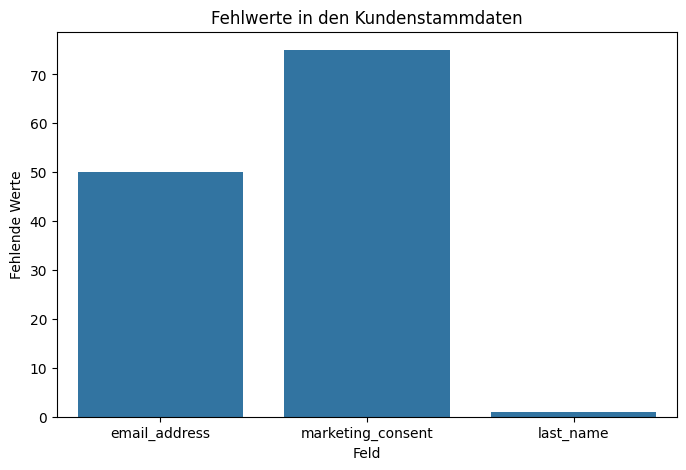

In [24]:
missing_customer_focus = pd.DataFrame({
    "Feld": ["email_address", "marketing_consent", "last_name"],
    "Fehlende Werte": [
        missing_email,
        missing_marketing,
        missing_lastname
    ]
})

plt.figure(figsize=(8,5))

sns.barplot(
    data=missing_customer_focus,
    x="Feld",
    y="Fehlende Werte"
)

plt.title("Fehlwerte in den Kundenstammdaten")
plt.show()

Beobachtung: Die größten Datenqualitätsprobleme betreffen die Felder marketing_consent (75 fehlende Werte) und email_address (50 fehlende Werte). Der Nachname fehlt nur bei einem Datensatz.

**Schritt 4 · Muster**

In [25]:
print("Marketing Consent:")
display(
    df_wald_k["marketing_consent"]
    .value_counts(dropna=False)
)

Marketing Consent:


,count
marketing_consent,
yes,85
NaN,75
no,67


In [26]:
print("Telefonnummern (Beispiele):")
display(
    df_wald_k["phone"]
    .dropna()
    .head(10)
)

Telefonnummern (Beispiele):


,phone
0,+49 645 01234
1,0645 09012
2,0640/777991
3,0640 7771212
4,0645 15588
5,0640 72224
6,+49 640 758420
7,+49 640 71132
8,+49 640 74451
9,+49 640 795781


In [27]:
# created_at in datetime umwandeln
df_wald_k["created_at_dt"] = pd.to_datetime(
    df_wald_k["created_at"],
    format="%m/%d/%Y",
    errors="coerce"
)

# ungültige Datumswerte zählen
invalid_created_at = df_wald_k["created_at_dt"].isna().sum()

print("Ungültige Datumswerte:")
print(invalid_created_at)

Ungültige Datumswerte:
5


Beobachtung: Telefonnummern liegen in unterschiedlichen Formaten vor (Leerzeichen, Schrägstrich, internationale Schreibweise). Das Feld created_at enthält 5 ungültige Datumswerte.

**Schritt 5 · Auffälligkeiten**

In [28]:
duplicate_customer_ids = (
    df_wald_k["customer_id"]
    .duplicated()
    .sum()
)

duplicate_emails = (
    df_wald_k["email_address"]
    .dropna()
    .duplicated()
    .sum()
)

print(f"Doppelte customer_id: {duplicate_customer_ids}")
print(f"Doppelte E-Mails: {duplicate_emails}")

Doppelte customer_id: 0
Doppelte E-Mails: 2


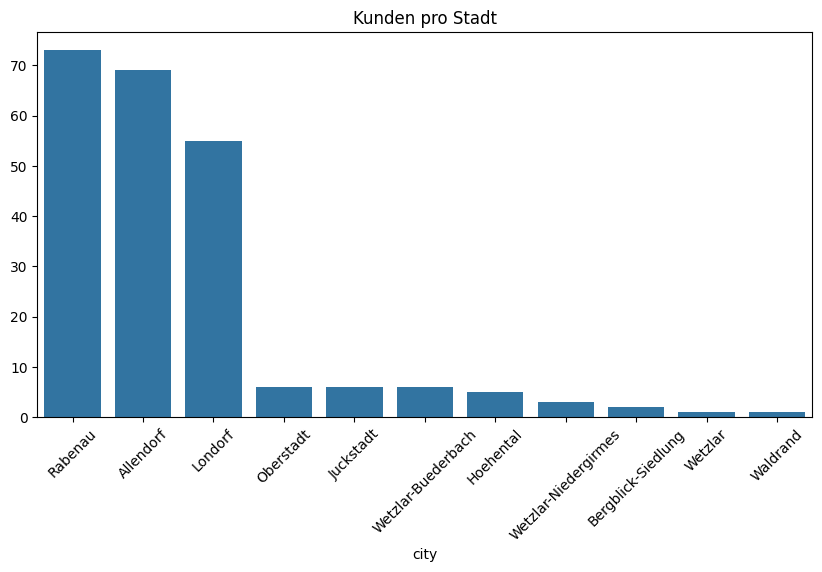

In [29]:
city_counts = df_wald_k["city"].value_counts()

plt.figure(figsize=(10,5))

sns.barplot(
    x=city_counts.index,
    y=city_counts.values
)

plt.title("Kunden pro Stadt")
plt.xticks(rotation=45)

plt.show()

Beobachtung: Die Kunden stammen überwiegend aus Rabenau, Allendorf und Londorf. Die Praxis besitzt ein klar regionales Einzugsgebiet.

### **4.2 · Profiling: Praxis Waldrand (behandlungen.csv)**

**Schritt 1 · Struktur**

In [30]:
print("=== Schritt 1: Struktur Behandlungen ===")

print(f"Format: CSV")
print(f"Zeilen: {len(df_wald_b)}")
print(f"Spalten: {len(df_wald_b.columns)}")
print(f"Spaltennamen: {list(df_wald_b.columns)}")

display(df_wald_b.head(3))

=== Schritt 1: Struktur Behandlungen ===
Format: CSV
Zeilen: 150
Spalten: 7
Spaltennamen: ['treatment_id', 'customer_id', 'animal_name', 'species', 'treatment_date', 'diagnosis', 'total_eur']


,treatment_id,customer_id,animal_name,species,treatment_date,diagnosis,total_eur
0,T20250151,W-1067,Smokey,cat,12/11/2025,Flea treatment,199.85
1,T20250152,W-1210,Kitty,cat,01/17/2026,Flea treatment,59.78
2,T20250153,W-1013,Felix,cat,03/22/2026,Ultrasound,35.02


Beobachtungg: Die Behandlungsdatei enthält 150 Datensätze mit Informationen zu Tierart, Diagnose, Behandlungsdatum und Rechnungsbetrag.

**Schritt 2 · Wertebereiche**

In [31]:
# total_eur in numerischen Betrag umwandeln
df_wald_b["total_eur_num"] = pd.to_numeric(
    df_wald_b["total_eur"],
    errors="coerce"
)

print(
    f"Minimum: {df_wald_b['total_eur_num'].min():.2f} €"
)

print(
    f"Maximum: {df_wald_b['total_eur_num'].max():.2f} €"
)

print(
    f"Durchschnitt: {df_wald_b['total_eur_num'].mean():.2f} €"
)

Minimum: 15.30 €
Maximum: 199.85 €
Durchschnitt: 114.89 €


In [32]:
display(
    df_wald_b["species"]
    .value_counts()
)

,count
species,
cat,76
dog,74


Beobachtung: Die Rechnungsbeträge bewegen sich zwischen 15,30 € und 199,85 €. Hunde und Katzen treten nahezu gleich häufig auf.

**Schritt 3 · Fehlwerte**

In [33]:
b_nulls = (
    df_wald_b
    .isna()
    .sum()
    .reset_index()
)

b_nulls.columns = [
    "Spalte",
    "Fehlwerte"
]

display(b_nulls)

,Spalte,Fehlwerte
0,treatment_id,0
1,customer_id,0
2,animal_name,0
3,species,0
4,treatment_date,0
5,diagnosis,0
6,total_eur,0
7,total_eur_num,0


Beobachtung: In den Behandlungsdaten treten keine relevanten Fehlwerte auf.

**Schritt 4 · Muster**

In [34]:
print(
    df_wald_b["species"]
    .value_counts(dropna=False)
)

species
cat    76
dog    74
Name: count, dtype: int64


In [35]:
print(
    df_wald_b["diagnosis"]
    .value_counts()
    .head(10)
)

diagnosis
Dressing change        13
Ultrasound             12
Check-up               11
X-ray                  11
Neutering               9
Eye examination         9
Dental scaling          9
Ear infection           9
Flea/tick treatment     8
Follow-up               8
Name: count, dtype: int64


In [36]:
# treatment_date in datetime umwandeln
df_wald_b["treatment_date_dt"] = pd.to_datetime(
    df_wald_b["treatment_date"],
    format="%m/%d/%Y",
    errors="coerce"
)

# total_eur in numerischen Betrag umwandeln
df_wald_b["total_eur_num"] = pd.to_numeric(
    df_wald_b["total_eur"],
    errors="coerce"
)

# ungültige Werte zählen
invalid_treatment_date = df_wald_b["treatment_date_dt"].isna().sum()
invalid_total_eur = df_wald_b["total_eur_num"].isna().sum()

print(
    f"Ungültige treatment_date-Werte: {invalid_treatment_date}"
)

print(
    f"Ungültige total_eur-Werte: {invalid_total_eur}"
)

Ungültige treatment_date-Werte: 0
Ungültige total_eur-Werte: 0


Beobachtung: Die Datums- und Betragsformate sind weitgehend konsistent. Die häufigsten Leistungen sind Dressing Change, Ultrasound, X-ray und Check-up.

**Schritt 5 · Auffälligkeiten**

In [37]:
duplicate_treatments = (
    df_wald_b["treatment_id"]
    .duplicated()
    .sum()
)

print(
    f"Doppelte treatment_id: "
    f"{duplicate_treatments}"
)

Doppelte treatment_id: 0


Beobchtung: Es wurden keine doppelten treatment_id-Werte gefunden.

In [38]:
df_wald_b["total_eur_num"] = pd.to_numeric(
    df_wald_b["total_eur"],
    errors="coerce"
)

df_wald_b["treatment_date_dt"] = pd.to_datetime(
    df_wald_b["treatment_date"],
    format="%m/%d/%Y",
    errors="coerce"
)

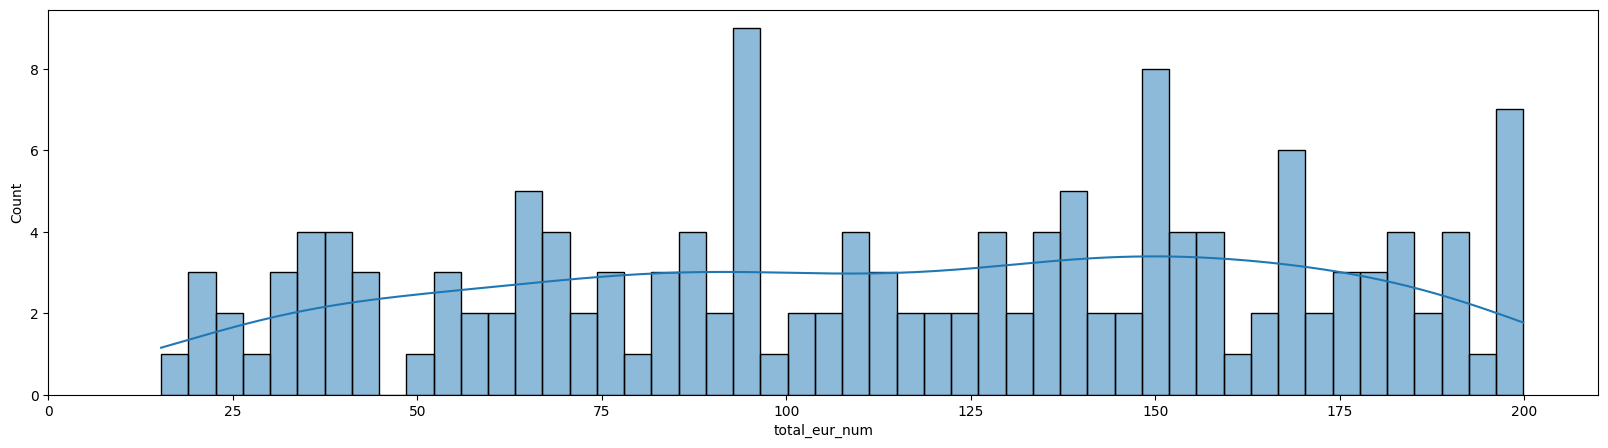

In [39]:
plt.figure(figsize=(20,5))

sns.histplot(
    df_wald_b["total_eur_num"],
    bins=50,
    kde=True
)

plt.xlim(0,210)

plt.show()

Beobachtung: Die Rechnungsbeträge verteilen sich relativ gleichmäßig zwischen 15 € und 200 €. Im Histogramm sind keine auffälligen Ausreißer erkennbar.

### **4.3 · Profiling: Praxis Waldrand (Vergleich und gemeinsame Analyse beider Dateien)**

**Join-Test Kunden und Behandlungen**

In [40]:
merged_wald = df_wald_b.merge(
    df_wald_k,
    on="customer_id",
    how="left", #Left Join
    indicator=True
)

join_summary = pd.DataFrame({
    "Kennzahl": [
        "Behandlungen gesamt",
        "Erfolgreich zugeordnet",
        "Nicht zugeordnet"
    ],
    "Wert": [
        len(df_wald_b),
        (merged_wald["_merge"] == "both").sum(),
        (merged_wald["_merge"] == "left_only").sum()
    ]
})

display(join_summary)

,Kennzahl,Wert
0,Behandlungen gesamt,150
1,Erfolgreich zugeordnet,150
2,Nicht zugeordnet,0


Beobachtung: Alle 150 Behandlungen konnten erfolgreich einem Kunden zugeordnet werden. Gleichzeitig enthält die Kundendatei 227 Datensätze und damit deutlich mehr Einträge als die Behandlungsdatei. Dies deutet darauf hin, dass nicht jeder Kunde eine dokumentierte Behandlung besitzt.

**Umsatz und Anzahl Behandlungen pro Kunde berechnen**

,customer_id,umsatz,anzahl_behandlungen
68,W-1155,647.26,5
46,W-1095,478.74,3
50,W-1101,478.43,3
93,W-1198,470.32,3
56,W-1118,407.67,4
87,W-1188,351.67,3
54,W-1108,349.98,2
34,W-1067,349.07,2
43,W-1087,317.07,2
1,W-1005,316.36,2


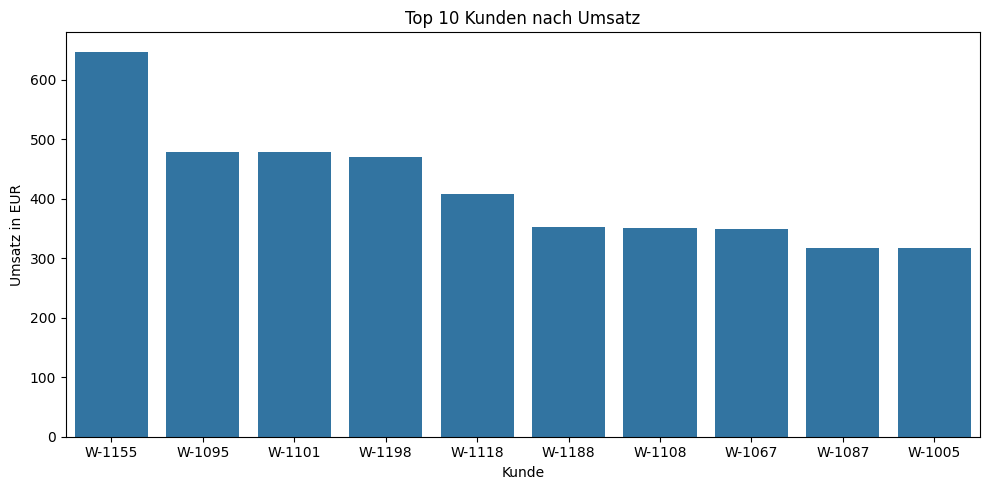

In [41]:
customer_activity = (
    df_wald_b
    .groupby("customer_id")
    .agg(
        umsatz=("total_eur_num", "sum"),
        anzahl_behandlungen=("treatment_id", "count")
    )
    .reset_index()
    .sort_values("umsatz", ascending=False)
)

# Top 10 Kunden anzeigen
display(customer_activity.head(10))

# Top 10 Kunden nach Umsatz visualisieren
top_customers = customer_activity.head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top_customers,
    x="customer_id",
    y="umsatz"
)

plt.title("Top 10 Kunden nach Umsatz")
plt.xlabel("Kunde")
plt.ylabel("Umsatz in EUR")
plt.tight_layout()
plt.show()

Bemerkung: Einige Kunden generieren deutlich höhere Umsätze als andere Kunden. Besonders Kunde W-1155 fällt mit rund 647 € Umsatz und fünf dokumentierten Behandlungen auf und könnte als Stammkunde betrachtet werden.

### **4.4 · Profiling: Praxis Waldrand (Finales Reporting)**

In [42]:
from datetime import datetime

# Hilfswerte für Kunden-Report berechnen

df_wald_k["created_at_dt"] = pd.to_datetime(
    df_wald_k["created_at"],
    format="%m/%d/%Y",
    errors="coerce"
)

missing_email = df_wald_k["email_address"].isna().sum()
missing_marketing = df_wald_k["marketing_consent"].isna().sum()
missing_lastname = df_wald_k["last_name"].isna().sum()

invalid_created_at = df_wald_k["created_at_dt"].isna().sum()

duplicate_customer_ids = df_wald_k["customer_id"].duplicated().sum()

duplicate_emails = (
    df_wald_k["email_address"]
    .dropna()
    .duplicated()
    .sum()
)

top_cities = df_wald_k["city"].value_counts().head(3)

# Report: Kunden

report_kunden = f"""# Profiling-Report: praxis_waldrand_kunden.csv

_Erstellt: {datetime.today().strftime('%Y-%m-%d')}_

## Schritt 1 · Struktur

| Merkmal | Wert |
|---|---|
| Format | CSV |
| Encoding | UTF-8 |
| Trennzeichen | Komma `,` |
| Header | ja |
| Zeilen | {len(df_wald_k)} |
| Spalten | {len(df_wald_k.columns)} |
| Spaltennamen | {', '.join(df_wald_k.columns)} |

**Beobachtung:** Die Kundendatei liegt als CSV-Datei mit UTF-8-Encoding vor und enthält {len(df_wald_k)} Kundendatensätze.

## Schritt 2 · Wertebereiche

| Feld | Distinct Values | Fehlwerte |
|---|---:|---:|
| customer_id | {df_wald_k["customer_id"].nunique()} | {df_wald_k["customer_id"].isna().sum()} |
| first_name | {df_wald_k["first_name"].nunique()} | {df_wald_k["first_name"].isna().sum()} |
| last_name | {df_wald_k["last_name"].nunique()} | {df_wald_k["last_name"].isna().sum()} |
| street | {df_wald_k["street"].nunique()} | {df_wald_k["street"].isna().sum()} |
| zip_code | {df_wald_k["zip_code"].nunique()} | {df_wald_k["zip_code"].isna().sum()} |
| city | {df_wald_k["city"].nunique()} | {df_wald_k["city"].isna().sum()} |
| phone | {df_wald_k["phone"].nunique()} | {df_wald_k["phone"].isna().sum()} |
| email_address | {df_wald_k["email_address"].nunique()} | {df_wald_k["email_address"].isna().sum()} |
| created_at | {df_wald_k["created_at"].nunique()} | {df_wald_k["created_at"].isna().sum()} |
| marketing_consent | {df_wald_k["marketing_consent"].nunique()} | {df_wald_k["marketing_consent"].isna().sum()} |

**Top-3 Städte:**

{top_cities.to_string()}

**Beobachtung:** Die Kunden verteilen sich auf mehrere Städte, wobei Rabenau, Allendorf und Londorf besonders häufig vorkommen.

## Schritt 3 · Fehlwerte

| Feld | Fehlwerte |
|---|---:|
| email_address | {missing_email} |
| marketing_consent | {missing_marketing} |
| last_name | {missing_lastname} |

**Beobachtung:** Die größten Datenqualitätsprobleme betreffen die Felder `marketing_consent` und `email_address`.

## Schritt 4 · Muster

| Feld | Muster | Auffälligkeiten |
|---|---|---|
| created_at | MM/DD/YYYY | {invalid_created_at} Werte nicht parsebar |
| phone | verschiedene Schreibweisen | uneinheitliche Telefonnummernformate |
| marketing_consent | yes / no / fehlend | {missing_marketing} fehlende Werte |
| email_address | E-Mail-Adresse | {missing_email} fehlende Werte |

**Beobachtung:** Telefonnummern liegen in unterschiedlichen Formaten vor. Außerdem konnten {invalid_created_at} Werte im Feld `created_at` nicht als gültiges Datum interpretiert werden.

## Schritt 5 · Auffälligkeiten

| Prüfung | Befund |
|---|---:|
| Doppelte customer_id | {duplicate_customer_ids} |
| Doppelte E-Mail-Adressen | {duplicate_emails} |
| Ungültige created_at-Werte | {invalid_created_at} |
| Fehlende E-Mail-Adressen | {missing_email} |
| Fehlende Marketing-Einwilligungen | {missing_marketing} |

**Fazit:** Die Kundendatei ist strukturell gut nutzbar, weist aber mehrere Datenqualitätsprobleme auf. Besonders relevant sind fehlende E-Mail-Adressen, fehlende Marketing-Einwilligungen, uneinheitliche Telefonnummernformate und ungültige Datumswerte im Feld `created_at`.
"""

with open("waldrand_kunden.md", "w", encoding="utf-8") as f:
    f.write(report_kunden)



In [43]:
# Hilfswerte für Behandlungen-Report berechnen

df_wald_b["treatment_date_dt"] = pd.to_datetime(
    df_wald_b["treatment_date"],
    format="%m/%d/%Y",
    errors="coerce"
)

df_wald_b["total_eur_num"] = pd.to_numeric(
    df_wald_b["total_eur"],
    errors="coerce"
)

invalid_treatment_date = df_wald_b["treatment_date_dt"].isna().sum()
invalid_total_eur = df_wald_b["total_eur_num"].isna().sum()

duplicate_treatments = df_wald_b["treatment_id"].duplicated().sum()

species_counts = df_wald_b["species"].value_counts()

diagnosis_top10 = df_wald_b["diagnosis"].value_counts().head(10)

total_missing_behandlungen = df_wald_b[
    [
        "treatment_id",
        "customer_id",
        "animal_name",
        "species",
        "treatment_date",
        "diagnosis",
        "total_eur"
    ]
].isna().sum().sum()

# Report: Behandlungen

report_behandlungen = f"""# Profiling-Report: praxis_waldrand_behandlungen.csv

_Erstellt: {datetime.today().strftime('%Y-%m-%d')}_

## Schritt 1 · Struktur

| Merkmal | Wert |
|---|---|
| Format | CSV |
| Encoding | UTF-8 |
| Trennzeichen | Komma `,` |
| Header | ja |
| Zeilen | {len(df_wald_b)} |
| Spalten | {len(df_wald_b.columns)} |
| Spaltennamen | {', '.join(df_wald_b.columns)} |

**Beobachtung:** Die Behandlungsdatei enthält {len(df_wald_b)} Datensätze mit Informationen zu Kunde, Tier, Behandlung, Datum und Rechnungsbetrag.

## Schritt 2 · Wertebereiche

| Kennzahl | Wert |
|---|---:|
| Minimaler Rechnungsbetrag | {df_wald_b["total_eur_num"].min():.2f} € |
| Maximaler Rechnungsbetrag | {df_wald_b["total_eur_num"].max():.2f} € |
| Durchschnittlicher Rechnungsbetrag | {df_wald_b["total_eur_num"].mean():.2f} € |
| Anzahl unterschiedlicher Tierarten | {df_wald_b["species"].nunique()} |
| Anzahl unterschiedlicher Diagnosen | {df_wald_b["diagnosis"].nunique()} |
| Anzahl unterschiedlicher Kunden in Behandlungen | {df_wald_b["customer_id"].nunique()} |

**Tierarten:**

{species_counts.to_string()}

**Beobachtung:** Die Rechnungsbeträge bewegen sich zwischen {df_wald_b["total_eur_num"].min():.2f} € und {df_wald_b["total_eur_num"].max():.2f} €. Hunde und Katzen treten nahezu gleich häufig auf.

## Schritt 3 · Fehlwerte

| Prüfung | Wert |
|---|---:|
| Fehlwerte gesamt | {total_missing_behandlungen} |
| Ungültige treatment_date-Werte | {invalid_treatment_date} |
| Ungültige total_eur-Werte | {invalid_total_eur} |

**Beobachtung:** In der Behandlungsdatei treten keine relevanten Fehlwerte auf.

## Schritt 4 · Muster

| Feld | Muster | Auffälligkeiten |
|---|---|---|
| treatment_date | MM/DD/YYYY | {invalid_treatment_date} Werte nicht parsebar |
| total_eur | numerischer Betrag mit Punkt | {invalid_total_eur} ungültige Werte |
| species | cat / dog | normierte Werte |
| diagnosis | Freitext / Leistung | mehrere unterschiedliche Diagnosen |

**Top-10 Diagnosen:**

{diagnosis_top10.to_string()}

**Beobachtung:** Die Datums- und Betragsformate sind weitgehend konsistent. Die häufigsten Leistungen sind Dressing Change, Ultrasound, X-ray und Check-up.

## Schritt 5 · Auffälligkeiten

| Prüfung | Befund |
|---|---:|
| Doppelte treatment_id | {duplicate_treatments} |
| Ungültige treatment_date-Werte | {invalid_treatment_date} |
| Ungültige total_eur-Werte | {invalid_total_eur} |

**Fazit:** Die Behandlungsdatei besitzt insgesamt eine hohe Datenqualität. Die Behandlungs-IDs sind eindeutig, Datums- und Betragswerte konnten erfolgreich verarbeitet werden, und es treten keine relevanten Fehlwerte auf. Die Rechnungsbeträge liegen in einem plausiblen Bereich zwischen ca. 15 € und 200 €.
"""

with open("waldrand_behandlungen.md", "w", encoding="utf-8") as f:
    f.write(report_behandlungen)

#**5 · Profiling: Praxis Schmidt**

### **Quelldateien laden**

**Bemerkung:** Vor der Analyse werden beide Quelldateien unverändert eingelesen. Die Kunden-CSV wird mit Pipe-Trennzeichen geladen, die Behandlungsdatei bleibt zuerst als originales JSON-Array in `raw_json` erhalten.

In [44]:
# Pfad-Konfiguration: lokal (Upload) oder Repo
# Wenn im Colab/lokal ohne Repo: Dateien direkt angeben
import os

REPO_DIR = "fallstudie_datenmanagement_master"
if os.path.exists(REPO_DIR):
    DATA_DIR = os.path.join(REPO_DIR, "verbund")
else:
    DATA_DIR = "."   # Dateien liegen im aktuellen Verzeichnis

FILE_KUNDEN     = os.path.join(DATA_DIR, "praxis_schmidt_kunden.csv")
FILE_BEHANDL    = os.path.join(DATA_DIR, "praxis_schmidt_behandlungen.json")

# ── CSV ───────────────────────────────────────────────────────────────────
df_k = pd.read_csv(FILE_KUNDEN, sep="|", dtype=str, encoding="utf-8")
print(f"praxis_schmidt_kunden.csv → {len(df_k)} Zeilen, {len(df_k.columns)} Spalten")
display(df_k.head(3))

# ── JSON ──────────────────────────────────────────────────────────────────
with open(FILE_BEHANDL, encoding="utf-8") as f:
    raw_json = json.load(f)

df_b = pd.json_normalize(raw_json)   # 'tier' Sub-Objekt wird geflattet
print(f"\npraxis_schmidt_behandlungen.json → {len(df_b)} Einträge")
print("Spalten nach json_normalize:", list(df_b.columns))
display(df_b.head(3))


praxis_schmidt_kunden.csv → 234 Zeilen, 9 Spalten


,nachname,vorname,anrede,plz,ort,strasse,tel,email,erfasst
0,Berger,Th.,Hr.,35500,Juckstadt,Hauptstr. 12,0645 01234,berger@email.de,06.12.2020
1,Hoffmann,Marion,Fr.,35500,Juckstadt,Kirchgasse 4,0645 02233,hoffmann@email.de,02.03.2024
2,Klaus,Weber,Hr.,35500,Juckstadt,Am Markt 3,0645 09012,weber@email.de,06.02.2024



praxis_schmidt_behandlungen.json → 150 Einträge
Spalten nach json_normalize: ['id', 'datum', 'kunde', 'leistung', 'betrag', 'tier.name', 'tier.art']


,id,datum,kunde,leistung,betrag,tier.name,tier.art
0,301,24.09.2025,Schneider X.,Vorsorgeuntersuchung,"15,46 EUR",Caesar,Katze
1,302,13.10.2025,Schneider T.,Kontrolle,"148,99 EUR",Tiger,Katze
2,303,24.03.2026,Muleler I.,Vorsorgeuntersuchung,"167,34 EUR",Caesar,Katze


### **5.1 · praxis_schmidt_kunden.csv Profiling**

#### **Schritt 1 · Struktur**
Format, Trennzeichen, Encoding, Spalten, Zeilenzahl.


In [45]:
print("=== Schritt 1: Struktur ===")
print(f"Format          : CSV")
print(f"Trennzeichen    : | (Pipe)")
print(f"Encoding        : UTF-8")
print(f"Zeilen          : {len(df_k)}")
print(f"Spalten         : {len(df_k.columns)}")
print(f"Spaltenname     : {list(df_k.columns)}")
print()
print("Erste 3 Zeilen:")
display(df_k.head(3))


=== Schritt 1: Struktur ===
Format          : CSV
Trennzeichen    : | (Pipe)
Encoding        : UTF-8
Zeilen          : 234
Spalten         : 9
Spaltenname     : ['nachname', 'vorname', 'anrede', 'plz', 'ort', 'strasse', 'tel', 'email', 'erfasst']

Erste 3 Zeilen:


,nachname,vorname,anrede,plz,ort,strasse,tel,email,erfasst
0,Berger,Th.,Hr.,35500,Juckstadt,Hauptstr. 12,0645 01234,berger@email.de,06.12.2020
1,Hoffmann,Marion,Fr.,35500,Juckstadt,Kirchgasse 4,0645 02233,hoffmann@email.de,02.03.2024
2,Klaus,Weber,Hr.,35500,Juckstadt,Am Markt 3,0645 09012,weber@email.de,06.02.2024


> **Beobachtung:** Die Kundendatei verwendet Pipe (`|`) als Trennzeichen und liegt in UTF-8 vor. Sie enthält 234 Datensätze mit 9 Spalten: Nachname, Vorname, Anrede, PLZ, Ort, Straße, Tel, E-Mail und Erfassungsdatum.


#### **Schritt 2 · Wertebereiche**
Typ-Vermutung, Minimum, Maximum, Distinct-Werte.


In [46]:
print("=== Schritt 2: Wertebereiche ===")

k_profil = pd.DataFrame({
    "Spalte"       : df_k.columns,
    "Typ-Vermutung": [guess_type(df_k[c]) for c in df_k.columns],
    "Beispiel"     : [example_val(df_k[c]) for c in df_k.columns],
    "Distinct"     : [distinct_count(df_k[c]) for c in df_k.columns],
    "Min"          : [df_k[c].dropna().min() if df_k[c].dtype == object else df_k[c].min() for c in df_k.columns],
    "Max"          : [df_k[c].dropna().max() if df_k[c].dtype == object else df_k[c].max() for c in df_k.columns],
    "Null%"        : [null_pct(df_k[c]) for c in df_k.columns],
})
display(k_profil)


=== Schritt 2: Wertebereiche ===


,Spalte,Typ-Vermutung,Beispiel,Distinct,Min,Max,Null%
0,nachname,VARCHAR,Berger,45,Albrecht,Zimmermann,0.0%
1,vorname,VARCHAR,Th.,68,Andreas,Zoey,0.0%
2,anrede,VARCHAR,Hr.,2,Fr.,Hr.,0.0%
3,plz,VARCHAR,35500,8,35466,35580,0.0%
4,ort,VARCHAR,Juckstadt,11,Allendorf,Wetzlar-Niedergirmes,0.0%
5,strasse,VARCHAR,Hauptstr. 12,225,Ahornweg 98,sonnenwall 50,0.0%
6,tel,VARCHAR,0645 01234,232,0605 085982,0645 17890,0.0%
7,email,VARCHAR,berger@email.de,206,albrecht.b@web.de,zimmermann.s@t-online.de,9.8%
8,erfasst,DATE,06.12.2020,224,01.01.2024,31.12.2025,0.0%


> **Beobachtung:** Alle Felder werden als VARCHAR erkannt. Das Erfassungsdatum (`erfasst`) ist im Format `DD.MM.YYYY` gespeichert – bei Staging muss dieses explizit als Datum geparst werden. Die PLZ hat ausschließlich 5-stellige Werte, was dem deutschen Standard entspricht.


#### **Schritt 3 · Fehlwerte**
Null-Anteil je Spalte.


In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

print("=== Schritt 3: Fehlwerte ===")

k_nulls = df_k.isna().sum().reset_index()
k_nulls.columns = ["Spalte", "Fehlwerte"]
k_nulls["Null%"] = (k_nulls["Fehlwerte"] / len(df_k) * 100).round(2)
display(k_nulls.sort_values("Null%", ascending=False))


=== Schritt 3: Fehlwerte ===


,Spalte,Fehlwerte,Null%
7,email,23,9.83
0,nachname,0,0.00
1,vorname,0,0.00
3,plz,0,0.00
2,anrede,0,0.00
4,ort,0,0.00
5,strasse,0,0.00
6,tel,0,0.00
8,erfasst,0,0.00


> **Beobachtung:** Nur die Spalte `email` weist fehlende Werte auf (23 Einträge, ~9,8 %). Alle anderen Felder sind vollständig befüllt.


#### **Schritt 4 · Muster**
Formate für Datum, Telefon, E-Mail, PLZ.


In [48]:
print("=== Schritt 4: Muster ===")

# Datum-Format prüfen
datum_pattern = r"^\d{2}\.\d{2}\.\d{4}$"
datum_ok = df_k["erfasst"].str.match(datum_pattern, na=False).sum()
print(f"Datum (DD.MM.YYYY) konform : {datum_ok}/{len(df_k)}")

# E-Mail-Format prüfen
email_pattern = r"^[^@\s]+@[^@\s]+\.[^@\s]+$"
email_valid   = df_k["email"].str.match(email_pattern, na=False).sum()
email_missing = df_k["email"].isna().sum()
email_invalid = len(df_k) - email_valid - email_missing
print(f"E-Mail gültig              : {email_valid}")
print(f"E-Mail fehlend             : {email_missing}")
print(f"E-Mail ungültiges Format   : {email_invalid}")

# Telefon-Format prüfen
tel_pattern  = r"^[+()0-9\s/-]{6,}$"
tel_invalid  = (~df_k["tel"].astype(str).str.match(tel_pattern, na=False)).sum()
print(f"Telefon auffällig          : {tel_invalid}")

# PLZ-Format prüfen (5-stellig)
plz_invalid  = (~df_k["plz"].astype(str).str.match(r"^\d{5}$", na=False)).sum()
print(f"PLZ auffällig              : {plz_invalid}")

# Vorname als Initial?
initialen = df_k["vorname"].str.match(r"^[A-ZÄÖÜa-z]\.$", na=False).sum()
print(f"Vorname als Initial        : {initialen}")

# Anrede-Werte
print(f"\nAnrede-Verteilung:")
display(df_k["anrede"].value_counts(dropna=False))


=== Schritt 4: Muster ===
Datum (DD.MM.YYYY) konform : 234/234
E-Mail gültig              : 211
E-Mail fehlend             : 23
E-Mail ungültiges Format   : 0
Telefon auffällig          : 0
PLZ auffällig              : 0
Vorname als Initial        : 7

Anrede-Verteilung:


,count
anrede,
Fr.,119
Hr.,115


> **Beobachtung:** Das Datumsformat `DD.MM.YYYY` ist konsistent. Bei 7 Datensätzen ist der Vorname nur als Initial (`X.`) angegeben – das erschwert späteres Matching. E-Mail und Telefon sind im gültigen Format, abgesehen von 23 fehlenden E-Mails.

> Anrede enthält nur `Hr.` und `Fr.` – dieses Feld ist normiert. Beide Anredegruppen sind fast gleich vertreten.


#### **Schritt 5 · Auffälligkeiten**
Ausreißer, kaputte Zeilen, Dubletten-Verdacht.


=== Schritt 5: Auffälligkeiten ===
Vollständig doppelte Zeilen  : 0
Gleicher Nachname + Ort      : 167 Datensätze betroffen
Doppelte E-Mail-Adressen     : 12

Telefon-Länge Min/Max/Mean   : 10 / 12 / 11.0

Erfassungen pro Jahr:


,count
erfasst_year,
2019,38
2020,40
2021,33
2022,37
2023,33
2024,35
2025,14
2026,3
2027,1


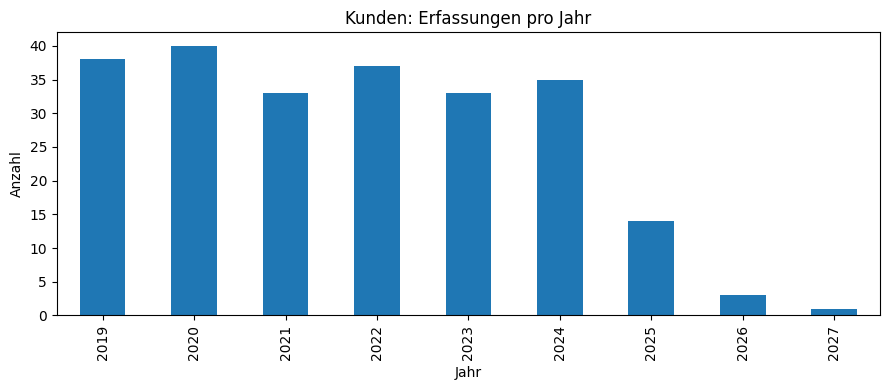

In [49]:
print("=== Schritt 5: Auffälligkeiten ===")

# Vollständige Dubletten
dupl_full = df_k.duplicated().sum()
print(f"Vollständig doppelte Zeilen  : {dupl_full}")

# Dubletten-Verdacht: gleicher Nachname + gleicher Ort
dupl_name_ort = df_k.duplicated(subset=["nachname", "ort"], keep=False).sum()
print(f"Gleicher Nachname + Ort      : {dupl_name_ort} Datensätze betroffen")

# Gleiche E-Mail → starker Dublettenhinweis
dupl_email = df_k[df_k["email"].notna()].duplicated(subset=["email"], keep=False).sum()
print(f"Doppelte E-Mail-Adressen     : {dupl_email}")

# Telefonnummern-Länge (Ausreißer?)
tel_len = df_k["tel"].str.len()
print(f"\nTelefon-Länge Min/Max/Mean   : {tel_len.min()} / {tel_len.max()} / {tel_len.mean():.1f}")

# Top-5 Erfassungsjahre (zeitliche Häufung)
df_k["erfasst_year"] = pd.to_datetime(df_k["erfasst"], format="%d.%m.%Y", errors="coerce").dt.year
print("\nErfassungen pro Jahr:")
display(df_k["erfasst_year"].value_counts().sort_index())

# Visualisierung: Erfassungen pro Jahr
fig, ax = plt.subplots(figsize=(9, 4))
df_k["erfasst_year"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title("Kunden: Erfassungen pro Jahr")
ax.set_xlabel("Jahr")
ax.set_ylabel("Anzahl")
plt.tight_layout()
plt.show()


> **Beobachtung:** Keine vollständig doppelten Zeilen. Es gibt jedoch Namens-/Orts-Kombinationen, die mehrfach vorkommen (mögliche Dubletten wie verschiedene Haustierbesitzer, aber auch Erfassungsfehler). Doppelte E-Mail-Adressen sind der stärkste Hinweis auf echte Dubletten.

> Die Masse der Erfassungen konzentriert sich auf wenige Jahre und es gibt erfasste Daten, die in der Zukunft liegen. Bezüglich dem Datenzufluss im Zeitverlauf sollte bei der Staging-Planung geachtet werden.


#### Markdown-Report

In [50]:
# Spaltenprofil-Tabelle erzeugen
_k_col_table = df_to_column_table(df_k)

_k_email_missing = int(df_k['email'].isna().sum())
_k_initialen     = int(df_k['vorname'].str.match(r'^[A-ZÄÖÜa-z]\.$', na=False).sum())
_k_dupl_email    = int(df_k[df_k['email'].notna()].duplicated(subset=['email'], keep=False).sum())
_k_dupl_full     = int(df_k.duplicated().sum())
_k_tel_invalid   = int((~df_k['tel'].astype(str).str.match(r'^[+()0-9\s/-]{6,}$', na=False)).sum())
_k_plz_invalid   = int((~df_k['plz'].astype(str).str.match(r'^\d{5}$', na=False)).sum())

report_k = f"""# Profiling-Report: praxis_schmidt_kunden.csv

_Erstellt: {datetime.today().strftime('%Y-%m-%d')}_

## Schritt 1 · Struktur

| Merkmal | Wert |
|---|---|
| Format | CSV |
| Trennzeichen | `|` (Pipe) |
| Encoding | UTF-8 |
| Header | ja |
| Zeilen | {len(df_k)} |
| Spalten | {len(df_k.columns)} |
| Spaltenname | {', '.join(df_k.columns)} |

## Schritt 2 · Wertebereiche

{_k_col_table}

## Schritt 3 · Fehlwerte

| Spalte | Fehlwerte | Null% |
|---|---:|---:|
| `email` | {_k_email_missing} | {_k_email_missing/len(df_k)*100:.1f}% |
| Alle anderen Spalten | 0 | 0.0% |

## Schritt 4 · Muster

| Feld | Muster | Auffälligkeiten |
|---|---|---|
| `erfasst` | `DD.MM.YYYY` | konsistent |
| `email` | `xxx@xxx.xxx` | {_k_email_missing} fehlend |
| `tel` | `XXXX XXXXX` | {_k_tel_invalid} auffällig |
| `plz` | 5-stellig | {_k_plz_invalid} auffällig |
| `vorname` | Vollname oder Initial | {_k_initialen}x nur Initial (`X.`) |
| `anrede` | `Hr.` / `Fr.` | normiert |

## Schritt 5 · Auffälligkeiten

| Prüfung | Befund |
|---|---|
| Vollständig doppelte Zeilen | {_k_dupl_full} |
| Doppelte E-Mail-Adressen | {_k_dupl_email} |
| Vorname als Initial | {_k_initialen} |
| Ungültige/fehlende E-Mail | {_k_email_missing} |

**Fazit:** Keine Duplikate auf Zeilenebene. Kritische Felder: `email` (fehlend) und `vorname` (Initialen), die das Matching in W9 erschwerden. Fehlende Kunden-ID erfordert alternatives Matching über Name + PLZ.
"""

write_report("schm_kunden.md", report_k)
print(report_k[:800])


  ✓ docs/w7_profiling/schm_kunden.md
# Profiling-Report: praxis_schmidt_kunden.csv

_Erstellt: 2026-06-07_

## Schritt 1 · Struktur

| Merkmal | Wert |
|---|---|
| Format | CSV |
| Trennzeichen | `|` (Pipe) |
| Encoding | UTF-8 |
| Header | ja |
| Zeilen | 234 |
| Spalten | 10 |
| Spaltenname | nachname, vorname, anrede, plz, ort, strasse, tel, email, erfasst, erfasst_year |

## Schritt 2 · Wertebereiche

| Spalte | Typ-Vermutung | Beispiel | Distinct | Null% | Bemerkung |
|---|---|---|---:|---:|---|
| `nachname` | VARCHAR | Berger | 45 | 0.0% |  |
| `vorname` | VARCHAR | Th. | 68 | 0.0% |  |
| `anrede` | VARCHAR | Hr. | 2 | 0.0% |  |
| `plz` | VARCHAR | 35500 | 8 | 0.0% |  |
| `ort` | VARCHAR | Juckstadt | 11 | 0.0% |  |
| `strasse` | VARCHAR | Hauptstr. 12 | 225 | 0.0% |  |
| `tel` | VARCHAR | 0645 01234 | 232 | 0.0% |  |
|


### **5.2 · Profiling der praxis_schmidt_behandlungen.json**



#### **Schritt 1 · Struktur**
Format, Trennzeichen, Encoding, Spalten, Zeilenzahl.


In [51]:
print("=== Schritt 1: Struktur ===")
print(f"Format           : JSON (Array of Objects)")
print(f"Encoding         : UTF-8")
print(f"Einträge (roh)   : {len(raw_json)}")
print(f"Einträge (flatted): {len(df_b)}")
print(f"Spalten          : {len(df_b.columns)}")
print(f"Spaltenname      : {list(df_b.columns)}")
print()
print("Beispiel-Eintrag (roh):")
print(json.dumps(raw_json[0], ensure_ascii=False, indent=2))
print()
print("Nach json_normalize (erste 3 Zeilen):")
display(df_b.head(3))


=== Schritt 1: Struktur ===
Format           : JSON (Array of Objects)
Encoding         : UTF-8
Einträge (roh)   : 150
Einträge (flatted): 150
Spalten          : 7
Spaltenname      : ['id', 'datum', 'kunde', 'leistung', 'betrag', 'tier.name', 'tier.art']

Beispiel-Eintrag (roh):
{
  "id": 301,
  "datum": "24.09.2025",
  "kunde": "Schneider X.",
  "tier": {
    "name": "Caesar",
    "art": "Katze"
  },
  "leistung": "Vorsorgeuntersuchung",
  "betrag": "15,46 EUR"
}

Nach json_normalize (erste 3 Zeilen):


,id,datum,kunde,leistung,betrag,tier.name,tier.art
0,301,24.09.2025,Schneider X.,Vorsorgeuntersuchung,"15,46 EUR",Caesar,Katze
1,302,13.10.2025,Schneider T.,Kontrolle,"148,99 EUR",Tiger,Katze
2,303,24.03.2026,Muleler I.,Vorsorgeuntersuchung,"167,34 EUR",Caesar,Katze


> **Beobachtung:** Die JSON-Datei ist ein Array mit 150 Objekten mit 7 Spalten. Das Feld `tier` ist ein verschachteltes Sub-Objekt mit `name` und `art`. Nach `json_normalize` entstehen daraus die Spalten `tier.name` und `tier.art`. Diese Verschachtelung muss vor dem Staging aufgelöst (geflattet) werden.



#### **Schritt 2 · Wertebereiche**
Typ-Vermutung, Minimum, Maximum, Distinct-Werte.


In [52]:
print("=== Schritt 2: Wertebereiche ===")

b_profil = pd.DataFrame({
    "Spalte"       : df_b.columns,
    "Datentyp"     : [guess_type(df_b[c]) for c in df_b.columns],
    "Beispiel"     : [example_val(df_b[c]) for c in df_b.columns],
    "Distinct"     : [distinct_count(df_b[c]) for c in df_b.columns],
    "Min"          : [df_b[c].dropna().min() if df_b[c].dtype == object else df_b[c].min() for c in df_b.columns],
    "Max"          : [df_b[c].dropna().max() if df_b[c].dtype == object else df_b[c].max() for c in df_b.columns],
    "Null%"        : [null_pct(df_b[c]) for c in df_b.columns],

})
display(b_profil)

# Betrag parsen für Wertebereich-Analyse
df_b["betrag_num"] = (
    df_b["betrag"].str.replace("EUR", "", regex=False)
                  .str.replace(",", ".", regex=False)
                  .str.strip()
)
df_b["betrag_num"] = pd.to_numeric(df_b["betrag_num"], errors="coerce")
print(f"\nbetrag_num – Min: {df_b['betrag_num'].min():.2f} EUR  "
      f"Max: {df_b['betrag_num'].max():.2f} EUR  "
      f"Mean: {df_b['betrag_num'].mean():.2f} EUR")

# Datum parsen
df_b["datum_dt"] = pd.to_datetime(df_b["datum"], format="%d.%m.%Y", errors="coerce")
print(f"datum_dt   – Frühestes: {df_b['datum_dt'].min().date()}  "
      f"Spätestes: {df_b['datum_dt'].max().date()}")

=== Schritt 2: Wertebereiche ===


,Spalte,Datentyp,Beispiel,Distinct,Min,Max,Null%
0,id,INTEGER,301,150,301,450,0.0%
1,datum,DATE,24.09.2025,108,01.01.2026,31.12.2025,0.0%
2,kunde,VARCHAR,Schneider X.,104,Albrecht S.,Zimmermann M.,0.0%
3,leistung,VARCHAR,Vorsorgeuntersuchung,19,Allergietest,Zeckenbefall Spot-On,0.0%
4,betrag,VARCHAR,"15,46 EUR",148,"100,08 EUR","97,46 EUR",0.0%
5,tier.name,VARCHAR,Caesar,32,Ace,Whiskey,0.0%
6,tier.art,VARCHAR,Katze,2,Hund,Katze,0.0%



betrag_num – Min: 15.46 EUR  Max: 199.50 EUR  Mean: 100.64 EUR
datum_dt   – Frühestes: 2025-09-01  Spätestes: 2026-04-04


**Beobachtung:**
> `id` ist eine INTEGER-Spalte (Behandlungs-ID). `betrag` liegt als String im Format `"XX,XX EUR"` vor und muss für Analysen geparst werden. Das Datumsfeld `datum` ist im Format `DD.MM.YYYY`.

> Die Beträge liegen zwischen ca. 15 EUR und 200 EUR. Der Zeitraum erstreckt sich von Sept. 2025 bis Apr. 2026.

>Das Spaltenprofil zeigt, dass die Behandlungsdaten vollständig gefüllt sind. Es gibt keine fehlenden Werte, keine komplett leeren Spalten und keine vollständig doppelten Zeilen.

#### **Schritt 3 · Fehlwerte**
Null-Anteil je Spalte.


In [53]:
print("=== Schritt 3: Fehlwerte ===")

b_nulls = df_b.drop(columns=["betrag_num", "datum_dt"], errors="ignore").isna().sum().reset_index()
b_nulls.columns = ["Spalte", "Fehlwerte"]
b_nulls["Null%"] = (b_nulls["Fehlwerte"] / len(df_b) * 100).round(2)
display(b_nulls.sort_values("Null%", ascending=False))

total_missing = b_nulls["Fehlwerte"].sum()
print(f"\nGesamt fehlende Werte: {total_missing}")



=== Schritt 3: Fehlwerte ===


,Spalte,Fehlwerte,Null%
0,id,0,0.0
1,datum,0,0.0
2,kunde,0,0.0
3,leistung,0,0.0
4,betrag,0,0.0
5,tier.name,0,0.0
6,tier.art,0,0.0



Gesamt fehlende Werte: 0


> **Beobachtung:** Keine fehlenden Werte in der Behandlungsdatei. Alle Pflichtfelder (`id`, `datum`, `kunde`, `leistung`, `betrag`, `tier.name`, `tier.art`) sind vollständig befüllt.


#### **Schritt 4 · Muster**
Formate für Datum, Betrag, Kundenname, Tierart.


In [54]:
print("=== Schritt 4: Muster ===")

# Datum-Format
datum_ok = df_b["datum"].str.match(r"^\d{2}\.\d{2}\.\d{4}$", na=False).sum()
print(f"Datum (DD.MM.YYYY) konform : {datum_ok}/{len(df_b)}")

# Betrag-Format
betrag_ok = df_b["betrag"].str.match(r"^\d+,\d{2} EUR$", na=False).sum()
betrag_invalid = len(df_b) - betrag_ok
print(f"Betrag-Format konform      : {betrag_ok}/{len(df_b)}")
print(f"Betrag-Format auffällig    : {betrag_invalid}")

# Kunden-Namensformat (Nachname Initiale.)
kunde_pattern_ok = df_b["kunde"].str.match(r"^[A-ZÄÖÜ][a-zäöüß]+ [A-ZÄÖÜ]\.$", na=False).sum()
print(f"Kundenname 'Nachname X.'   : {kunde_pattern_ok}/{len(df_b)}")
print()

# Tierart-Verteilung
print("Tierart-Verteilung:")
display(df_b["tier.art"].value_counts(dropna=False))

# Leistungs-Verteilung (Top 10)
print("\nTop 10 Leistungen:")
display(df_b["leistung"].value_counts().head(10))


=== Schritt 4: Muster ===
Datum (DD.MM.YYYY) konform : 150/150
Betrag-Format konform      : 150/150
Betrag-Format auffällig    : 0
Kundenname 'Nachname X.'   : 150/150

Tierart-Verteilung:


,count
tier.art,
Katze,75
Hund,75



Top 10 Leistungen:


,count
leistung,
Allergietest,15
Zeckenbefall Spot-On,13
Kontrolle,12
Kastration,11
Vorsorgeuntersuchung,11
Tumorabklaerung,10
Lahmheitsuntersuchung,10
Floehe Behandlung,10
Ultraschall,9


> **Beobachtung:** Das Datumsformat ist durchgängig `DD.MM.YYYY`. Beträge folgen dem Muster `XX,XX EUR` mit Komma-Dezimaltrenner, das Format muss beim Staging konvertiert werden.

> Das Kundenfeld `kunde` folgt dem Format `Nachname X.` (Initiale), was bei der Verknüpfung mit der Kundendatei zu erschwertem Matching führt, da dort vollständige Vornamen (oder ebenfalls Initialen) vorkommen können.

> Tierart: nur `Katze` und `Hund`, welches auf ein sauber normiertes Feld hindeutet.

> Die häufigsten Behandlungen sind Allergietests, Zeckenbefall-Spot-On und Kontrollen. Die Werte liegen insgesamt relativ nah beieinander, daher verteilt sich das Behandlungsspektrum recht breit und wird nicht nur von einer einzelnen Leistung dominiert.


#### **Schritt 5 · Auffälligkeiten**
Ausreißer, Dubletten-Verdacht, Querverweis auf Kundendatei.


=== Schritt 5: Auffälligkeiten ===
Vollständig doppelte Zeilen     : 0
Doppelte Behandlungs-ID         : 0
Betrags-Ausreißer (IQR)         : 0

Behandlungen pro Monat:


,monat,anzahl
0,2025-09,29
1,2025-10,22
2,2025-11,12
3,2025-12,21
4,2026-01,17
5,2026-02,21
6,2026-03,22
7,2026-04,6


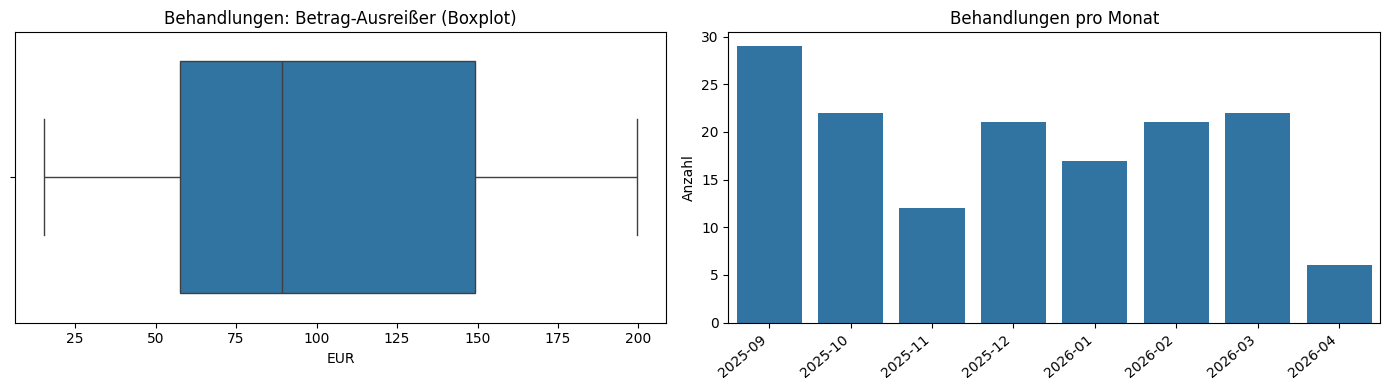


--- Querverweis: Kunden-Abgleich ---
Behandlungen mit Kunden-Match  : 150/150
Behandlungen OHNE Kunden-Match : 0/150
→ Kein direktes ID-Matching möglich; Name-basiertes Matching nötig.


In [55]:
print("=== Schritt 5: Auffälligkeiten ===")

# Vollständige Dubletten
dupl_full_b = df_b.drop(columns=["betrag_num", "datum_dt"], errors="ignore").duplicated().sum()
print(f"Vollständig doppelte Zeilen     : {dupl_full_b}")

# Gleiche ID mehrfach?
dupl_id = df_b["id"].duplicated().sum()
print(f"Doppelte Behandlungs-ID         : {dupl_id}")

# Ausreißer-Check Beträge (IQR-Methode)
q1, q3 = df_b["betrag_num"].quantile(0.25), df_b["betrag_num"].quantile(0.75)
iqr = q3 - q1
ausreisser = df_b[(df_b["betrag_num"] < q1 - 1.5*iqr) | (df_b["betrag_num"] > q3 + 1.5*iqr)]
print(f"Betrags-Ausreißer (IQR)         : {len(ausreisser)}")
if len(ausreisser) > 0:
    display(ausreisser[["id", "datum", "kunde", "leistung", "betrag"]])

# Behandlungen pro Monat (zeitliche Lücken?)
monate = df_b.dropna(subset=["datum_dt"]).assign(
    monat=lambda x: x["datum_dt"].dt.to_period("M").astype(str)
).groupby("monat").size().reset_index(name="anzahl")
print("\nBehandlungen pro Monat:")
display(monate)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
# Boxplot Beträge
sns.boxplot(x=df_b["betrag_num"].dropna(), ax=axes[0])
axes[0].set_title("Behandlungen: Betrag-Ausreißer (Boxplot)")
axes[0].set_xlabel("EUR")
# Monatsverteilung
sns.barplot(data=monate, x="monat", y="anzahl", ax=axes[1])
axes[1].set_title("Behandlungen pro Monat")
axes[1].set_xlabel("")
axes[1].set_ylabel("Anzahl")
plt.setp(axes[1].get_xticklabels(), rotation=40, ha="right")
plt.tight_layout()
plt.show()

# Querverweis: Kunden-Matching
print("\n--- Querverweis: Kunden-Abgleich ---")
# Schlüssel in Kundendatei: "Nachname Initiale."
df_k_temp = df_k.copy()
df_k_temp["kunde_key"] = df_k_temp["nachname"] + " " + df_k_temp["vorname"].str[0] + "."
kunden_keys = set(df_k_temp["kunde_key"])
match_rate  = df_b["kunde"].isin(kunden_keys).sum()
no_match    = len(df_b) - match_rate
print(f"Behandlungen mit Kunden-Match  : {match_rate}/{len(df_b)}")
print(f"Behandlungen OHNE Kunden-Match : {no_match}/{len(df_b)}")
print("→ Kein direktes ID-Matching möglich; Name-basiertes Matching nötig.")


> **Beobachtung:** Keine doppelten IDs und keine vollständig duplizierten Zeilen. Die Rechnungsbeträge verteilen sich über einen breiten Bereich von ungefähr 15 bis 200 EUR. Im Boxplot sind keine klaren Ausreißer erkennbar, daher wirken die Beträge insgesamt plausibel und nicht auffällig.

> Der niedrige Kunden-Match bei direktem Namen-Abgleich liegt an Formatunterschieden (Initialen vs. volle Namen). Ein Fuzzy-Matching oder Normalisierungsstep wird in W9 benötigt.

> Die Behandlungsdaten reichen vom 01.09.2025 bis 04.04.2026. Die monatlichen Fallzahlen schwanken sichtbar; besonders der April 2026 ist mit nur 6 Behandlungen auffällig niedrig. Das kann daran liegen, dass dieser Monat im Datensatz nur teilweise enthalten ist.


####  Markdown-Report


In [56]:
_b_col_table = df_to_column_table(df_b.drop(columns=["betrag_num", "datum_dt"], errors="ignore"))
_b_dupl     = int(df_b.drop(columns=["betrag_num","datum_dt"],errors="ignore").duplicated().sum())
_b_dupl_id  = int(df_b["id"].duplicated().sum())
_b_ausreiss = len(ausreisser)
_b_betrag_inv = len(df_b) - int(df_b["betrag"].str.match(r"^\d+,\d{2} EUR$", na=False).sum())
_b_datum_inv  = int(df_b["datum_dt"].isna().sum())
_b_no_match   = no_match

report_b = f"""# Profiling-Report: praxis_schmidt_behandlungen.json

_Erstellt: {datetime.today().strftime('%Y-%m-%d')}_

## Schritt 1 · Struktur

| Merkmal | Wert |
|---|---|
| Format | JSON (Array of Objects) |
| Encoding | UTF-8 |
| Header | nein (JSON-Keys) |
| Einträge (roh) | {len(raw_json)} |
| Spalten nach Flatten | {len(df_b.drop(columns=['betrag_num','datum_dt'], errors='ignore').columns)} |
| Verschachtelung | `tier` → `tier.name`, `tier.art` |

## Schritt 2 · Wertebereiche

{_b_col_table}

**Betrag (geparst):** Min {df_b['betrag_num'].min():.2f} EUR – Max {df_b['betrag_num'].max():.2f} EUR – Mean {df_b['betrag_num'].mean():.2f} EUR
**Datum:** {df_b['datum_dt'].min().date()} bis {df_b['datum_dt'].max().date()}

## Schritt 3 · Fehlwerte

Keine fehlenden Werte. Alle {len(df_b)} Datensätze sind vollständig.

## Schritt 4 · Muster

| Feld | Muster | Auffälligkeiten |
|---|---|---|
| `datum` | `DD.MM.YYYY` | konsistent, {_b_datum_inv} nicht parsebar |
| `betrag` | `XX,XX EUR` | Komma-Dezimaltrenner; {_b_betrag_inv} auffällig |
| `kunde` | `Nachname X.` | Initiale statt Vorname; erschwertes Matching |
| `tier.art` | `Katze` / `Hund` | normiert, nur 2 Ausprägungen |

## Schritt 5 · Auffälligkeiten

| Prüfung | Befund |
|---|---|
| Vollständig doppelte Zeilen | {_b_dupl} |
| Doppelte Behandlungs-ID | {_b_dupl_id} |
| Betrags-Ausreißer (IQR) | {_b_ausreiss} |
| Behandlungen ohne Kunden-Match | {_b_no_match} |

**Fazit:** Die Behandlungsdatei ist vollständig und konsistent. Kritische Punkte: (1) `betrag` als String muss geparst werden, (2) `tier` muss vor Staging geflattet werden, (3) Kunden-Matching erfordert name-basierte Normalisierung, da keine gemeinsame ID vorhanden ist.
"""

write_report("schm_behandlungen.md", report_b)
print(report_b[:800])


  ✓ docs/w7_profiling/schm_behandlungen.md
# Profiling-Report: praxis_schmidt_behandlungen.json

_Erstellt: 2026-06-07_

## Schritt 1 · Struktur

| Merkmal | Wert |
|---|---|
| Format | JSON (Array of Objects) |
| Encoding | UTF-8 |
| Header | nein (JSON-Keys) |
| Einträge (roh) | 150 |
| Spalten nach Flatten | 7 |
| Verschachtelung | `tier` → `tier.name`, `tier.art` |

## Schritt 2 · Wertebereiche

| Spalte | Typ-Vermutung | Beispiel | Distinct | Null% | Bemerkung |
|---|---|---|---:|---:|---|
| `id` | INTEGER | 301 | 150 | 0.0% |  |
| `datum` | DATE | 24.09.2025 | 108 | 0.0% |  |
| `kunde` | VARCHAR | Schneider X. | 104 | 0.0% |  |
| `leistung` | VARCHAR | Vorsorgeuntersuchung | 19 | 0.0% |  |
| `betrag` | VARCHAR | 15,46 EUR | 148 | 0.0% |  |
| `tier.name` | VARCHAR | Caesar | 32 | 0.0% |  |
| `tier.art` | VARCHAR | Katze | 2 | 


### **5.3 · Vergleich beider Dateien**

In [57]:
kunden_id_col = next((col for col in df_k.columns if any(key in col.lower() for key in ["kunden_id", "kunde_id", "customer_id", "id"])), None)
behandlung_kunden_id_col = next((col for col in df_b.columns if any(key in col.lower() for key in ["kunden_id", "kunde_id", "customer_id", "halter_id"])), None)

if kunden_id_col and behandlung_kunden_id_col:
    kunden_ids = set(df_k[kunden_id_col].dropna().astype(str))
    behandlung_ids = df_b[behandlung_kunden_id_col].dropna().astype(str)
    unbekannte_kunden = int((~behandlung_ids.isin(kunden_ids)).sum())
    print(f"Kunden-ID-Spalte Kunden: {kunden_id_col}")
    print(f"Kunden-ID-Spalte Behandlungen: {behandlung_kunden_id_col}")
    print(f"Behandlungen mit unbekannter Kunden-ID: {unbekannte_kunden}")
else:
    unbekannte_kunden = "Keine passenden Kunden-ID-Spalten gefunden"
    print(unbekannte_kunden)

Keine passenden Kunden-ID-Spalten gefunden


> **Beobachtung**: In den Kunden- und Behandlungsdaten wurden keine passenden Kunden-ID-Spalten gefunden. Ein direkter Abgleich über eine eindeutige ID ist daher nicht möglich. Für eine spätere Verknüpfung der Daten müssten alternative Merkmale wie Name oder andere Kundeninformationen genutzt werden.

In [58]:
# Prepare df_k for merging by creating a 'kunde_key'
df_k_temp = df_k.copy()
df_k_temp['kunde_key'] = df_k_temp['nachname'] + ' ' + df_k_temp['vorname'].str[0] + '.'

# Perform a left merge from treatments to customers
merged_schm = df_b.merge(
    df_k_temp,
    left_on='kunde',
    right_on='kunde_key',
    how='left'
)

print("--- Vergleich von kunden und behandlungen ---")
print(f"Anzahl der Behandlungen: {len(df_b)}")
print(f"Anzahl der Kunden: {len(df_k)}")
print(f"Anzahl der Behandlungen mit passendem Kunden-Eintrag: {merged_schm['nachname'].notna().sum()}")
print(f"Anzahl der Behandlungen OHNE passenden Kunden-Eintrag: {merged_schm['nachname'].isna().sum()}")

--- Vergleich von kunden und behandlungen ---
Anzahl der Behandlungen: 150
Anzahl der Kunden: 234
Anzahl der Behandlungen mit passendem Kunden-Eintrag: 187
Anzahl der Behandlungen OHNE passenden Kunden-Eintrag: 0


>**Beobachtung**: Alle Behandlungen konnten einem Kunden-Eintrag zugeordnet werden, da es 0 Behandlungen ohne passenden Kunden gibt. Allerdings ist die Anzahl der gematchten Zeilen (187) höher als die ursprüngliche Anzahl der Behandlungen (150). Das deutet darauf hin, dass der Join Mehrfachtreffer erzeugt, vermutlich weil der Schlüssel kunde_key nicht eindeutig ist. Daher kann kunde_key allein nicht zuverlässig für das Matching verwendet werden.

# 9 · Profiling: berg_export (XML mit Namespace)

## 9 · Profiling: Praxis Bergblick

Dieser Abschnitt ist der abgabefertige Profiling-Teil für **Praxis Bergblick**.

**Besonderheit der Quelle:** Bergblick liefert die Daten nicht als flache CSV-Datei, sondern als **XML-Export mit Namespace**. Die Daten sind verschachtelt aufgebaut: Ein `patient` enthält Halter-, Kontakt-, Adress- und Tierinformationen; Behandlungen werden separat gespeichert und referenzieren Patienten über eine ID.

**Ziel des Profilings:**
- XML-Struktur verstehen
- Daten in tabellarische Form bringen
- Patienten/Halter/Tiere und Behandlungen getrennt analysieren
- Datenqualitätsprobleme erkennen
- Auswirkungen auf Staging, Transform und spätere Rejects dokumentieren


### 9.1 Hilfsfunktionen für Bergblick

Diese Zelle definiert kleine Hilfsfunktionen für das Profiling.  
Sie sorgen dafür, dass fehlende Werte sauber erkannt werden, Spaltenprofile erstellt werden können und die Markdown-Reports später automatisch geschrieben werden.


In [59]:
OUT_DIR = Path("docs/w7_profiling")
OUT_DIR.mkdir(parents=True, exist_ok=True)

def null_pct(series: pd.Series) -> str:
    """Berechnet den Anteil fehlender Werte als Prozentwert."""
    pct = series.isna().mean() * 100
    return f"{pct:.1f}%"

def distinct_count(series: pd.Series) -> int:
    """Zählt unterschiedliche Werte inklusive fehlender Werte."""
    return series.nunique(dropna=False)

def example_val(series: pd.Series):
    """Gibt einen Beispielwert aus einer Spalte zurück."""
    non_null = series.dropna()
    if len(non_null) == 0:
        return "–"
    return str(non_null.iloc[0])[:80]

def guess_type(series: pd.Series) -> str:
    """Grobe Typ-Vermutung für Profiling-Bericht."""
    s = series.dropna().astype(str)
    if len(s) == 0:
        return "VARCHAR"
    if s.str.match(r"^\d{4}-\d{2}-\d{2}$").all():
        return "DATE"
    if s.str.match(r"^\d+([.,]\d+)?$").all():
        return "NUMERIC"
    return "VARCHAR"

def df_to_column_table(df: pd.DataFrame) -> str:
    """Erstellt eine Markdown-Tabelle mit Profiling-Informationen je Spalte."""
    rows = []
    for col in df.columns:
        rows.append({
            "Spalte": col,
            "Typ-Vermutung": guess_type(df[col]),
            "Beispiel": example_val(df[col]),
            "Distinct": df[col].nunique(dropna=True),
            "Null%": null_pct(df[col]),
            "Bemerkung": ""
        })
    return pd.DataFrame(rows).to_markdown(index=False)

def write_report(filename: str, text: str):
    """Schreibt einen Markdown-Report in docs/w7_profiling."""
    path = OUT_DIR / filename
    path.write_text(text, encoding="utf-8")
    print(f"✓ Report geschrieben: {path}")

print("Bergblick-Hilfsfunktionen geladen.")

Bergblick-Hilfsfunktionen geladen.




Die Hilfsfunktionen sind die technische Grundlage für das eigentliche Profiling. Wichtig ist hier vor allem, dass die Ausgabe automatisch als Markdown erzeugt wird. Dadurch entstehen direkt die Dateien: `berg_patienten.md` und `berg_behandlungen.md`.

Hier durch ist das Profiling reproduzierbar: Wenn sich die Quelldaten ändern oder das Notebook erneut ausgeführt wird, werden die Reports automatisch neu erzeugt.


### 9.2 XML-Datei laden und Grundstruktur prüfen

Nun wird die Bergblick-XML-Datei geladen. Danach wird geprüft:
- Wie heißt das Root-Element?
- Gibt es einen Namespace?
- Welche direkten Kind-Elemente besitzt die XML-Datei?

Das ist bei XML wichtig, weil ein Parser ohne Namespace-Handling viele Elemente nicht findet.


In [60]:
if "DATA_DIR" not in globals():
    DATA_DIR = "fallstudie_datenmanagement_master/verbund"

FILE = os.path.join(DATA_DIR, "praxis_bergblick_export.xml")

if not os.path.exists(FILE):
    raise FileNotFoundError(
        f"Datei nicht gefunden: {FILE}\n"
        "Prüfe, ob das Repository geklont wurde und DATA_DIR korrekt gesetzt ist."
    )

tree = etree.parse(FILE)
root = tree.getroot()

# Namespace automatisch erkennen
NS = root.nsmap
ns_uri = list(NS.values())[0] if NS else ""
ns_prefix = f"{{{ns_uri}}}" if ns_uri else ""

print("Datei:", FILE)
print("Root-Tag:", root.tag.split("}")[-1])
print("Namespace:", ns_uri if ns_uri else "kein Namespace erkannt")
print("Anzahl direkter Kinder:", len(root))
print("Erste Kinder-Tags:", [child.tag.split('}')[-1] for child in root[:5]])

Datei: fallstudie_datenmanagement_master/verbund/praxis_bergblick_export.xml
Root-Tag: praxisexport
Namespace: http://vetkliniken-hessen.de/schema/v2
Anzahl direkter Kinder: 3
Erste Kinder-Tags: ['praxis', 'patienten', 'behandlungen']



Das ausgeführte Profiling zeigt:

- Datei: `praxis_bergblick_export.xml`
- Root-Tag: `praxisexport`
- Namespace: `http://vetkliniken-hessen.de/schema/v2`
- Direkte Kinder: `praxis`, `patienten`, `behandlungen`

Das ist wichtig, weil Bergblick technisch anders aufgebaut ist als die CSV-Quellen. Die Daten liegen nicht direkt in Spalten vor, sondern innerhalb eines XML-Baums. Der Namespace ist ein zusätzliches technisches Risiko: XPath- oder `.find()`-Abfragen müssen namespace-aware sein, sonst werden Elemente nicht gefunden und später entstehen künstliche Fehlwerte oder Rejects.


### 9.3 XML-Flattening durchführen

Als nächstes wird die XML-Struktur in zwei flache Tabellen verwandelt:

1. `df_berg_p` für Patienten, Halter und Tiere  
2. `df_berg_b` für Behandlungen

Dabei werden sowohl **Kind-Elemente** als auch **Attribute** ausgelesen. Das ist wichtig, weil Bergblick relevante Werte wie `patientId`, `datum`, `netto` und `brutto` teilweise als XML-Attribute speichert.


In [61]:
def xml_tag(name: str) -> str:
    """Erzeugt Tag-Namen inklusive Namespace."""
    return f"{ns_prefix}{name}"

def text_or_none(element):
    """Liest Text aus XML-Elementen."""
    if element is None or element.text is None:
        return None
    value = element.text.strip()
    return value if value != "" else None

def find_text(parent, tag_name: str):
    """Sucht ein Kind-Element und gibt dessen Text zurück."""
    if parent is None:
        return None
    return text_or_none(parent.find(xml_tag(tag_name)))

def get_attr(element, attr_name: str):
    """Liest ein XML-Attribut aus."""
    if element is None:
        return None
    value = element.get(attr_name)
    return value.strip() if value else None

patienten_rows = []
behandlung_rows = []

# Patienten/Halter/Tiere extrahieren
for pos, patient in enumerate(root.iter(xml_tag("patient")), start=1):
    halter = patient.find(xml_tag("halter"))
    tier = patient.find(xml_tag("tier"))

    row = {
        "xml_position": pos,
        "patient_id": get_attr(patient, "id"),
        "patient_quell_id": get_attr(patient, "id"),
    }

    if halter is not None:
        row["halter_id"] = get_attr(halter, "id") or get_attr(patient, "id")
        row["halter_anrede"] = find_text(halter, "anrede")
        row["halter_name"] = find_text(halter, "name")
        row["halter_vorname"] = find_text(halter, "vorname")
        row["halter_nachname"] = find_text(halter, "nachname")

        kontakt = halter.find(xml_tag("kontakt"))
        if kontakt is not None:
            telefon = kontakt.find(xml_tag("telefon"))
            row["halter_telefon"] = text_or_none(telefon)
            row["halter_telefon_typ"] = get_attr(telefon, "typ")
            row["halter_email"] = find_text(kontakt, "email")

        adresse = halter.find(xml_tag("adresse"))
        if adresse is not None:
            row["halter_strasse"] = find_text(adresse, "strasse")
            row["halter_plz"] = find_text(adresse, "plz")
            row["halter_ort"] = find_text(adresse, "ort")

    if tier is not None:
        row["tier_id"] = get_attr(tier, "id")
        row["tier_name"] = find_text(tier, "name")
        row["tier_art"] = find_text(tier, "art")
        row["tier_geburt"] = find_text(tier, "geburt")

    patienten_rows.append(row)

# Behandlungen extrahieren
for pos, behandlung in enumerate(root.iter(xml_tag("behandlung")), start=1):
    summe = behandlung.find(xml_tag("summe"))

    row = {
        "xml_position": pos,
        "behandlung_id": get_attr(behandlung, "id"),
        "patient_id": get_attr(behandlung, "patientId"),
        "datum": get_attr(behandlung, "datum"),
        "diagnose": find_text(behandlung, "diagnose"),
        "leistung": find_text(behandlung, "leistung"),
        "kosten_netto": get_attr(summe, "netto"),
        "kosten_brutto": get_attr(summe, "brutto"),
    }

    behandlung_rows.append(row)

df_berg_p = pd.DataFrame(patienten_rows)
df_berg_b = pd.DataFrame(behandlung_rows)

print(f"Patienten/Halter/Tiere: {len(df_berg_p)} Zeilen, {len(df_berg_p.columns)} Spalten")
print(f"Behandlungen: {len(df_berg_b)} Zeilen, {len(df_berg_b.columns)} Spalten")

print("\nVorschau Patienten/Halter/Tiere:")
display(df_berg_p.head(5))

print("\nVorschau Behandlungen:")
display(df_berg_b.head(5))

Patienten/Halter/Tiere: 232 Zeilen, 18 Spalten
Behandlungen: 150 Zeilen, 8 Spalten

Vorschau Patienten/Halter/Tiere:


,xml_position,patient_id,patient_quell_id,halter_id,halter_anrede,halter_name,halter_vorname,halter_nachname,halter_telefon,halter_telefon_typ,halter_email,halter_strasse,halter_plz,halter_ort,tier_id,tier_name,tier_art,tier_geburt
0,1,P-4001,P-4001,P-4001,Herr,Thomas Berger,None,None,0645-01234,festnetz,berger@email.de,Hauptstrasse 12,35500,Juckstadt,None,Lucky,Hund,2022-05-03
1,2,P-4002,P-4002,P-4002,Frau,Marion Hoffmann,None,None,0645-02233,mobil,hoffmann@email.de,Kirchgasse 4,35500,Juckstadt,None,Buddy,Hund,2021-11-18
2,3,P-4003,P-4003,P-4003,Frau,Petra Vogel,None,None,0640-7779913,festnetz,vogel@email.de,Eichenallee 8,35466,Rabenau,None,Luna,Hund,2020-05-09
3,4,P-4004,P-4004,P-4004,Herr,B. Schulz,None,None,0640-7771212,mobil,schulz@email.de,Dorfstr. 44,35466,Rabenau,None,Lola,Hund,2019-05-07
4,5,P-4005,P-4005,P-4005,Frau,Bettina Klein,None,None,0645-020031,privat,klein.b@gmx.de,Bergstr. 9,35510,Waldrand,None,Buddy,Hund,2021-03-11



Vorschau Behandlungen:


,xml_position,behandlung_id,patient_id,datum,diagnose,leistung,kosten_netto,kosten_brutto
0,1,None,P-4191,2025-11-15,Tumorabklaerung,None,162.92,193.87
1,2,None,P-4094,2025-11-02,Zahnsteinentfernung,None,32.55,38.73
2,3,None,P-4036,2026-03-12,Allergietest,None,161.95,192.72
3,4,None,P-4026,2025-09-22,Tumorabklaerung,None,135.18,160.86
4,5,None,P-4085,2026-01-22,Tumorabklaerung,None,71.45,85.02




Das ausgeführte Skript erzeugt:

- `df_berg_p`: **232 Zeilen** und **18 Spalten**
- `df_berg_b`: **150 Zeilen** und **8 Spalten**

Damit wurde die XML-Datei erfolgreich in zwei tabellarische Strukturen überführt. Dies ist notwendig um spätere Pipeline-Schritte wie Staging, Transformation, Matching und Qualitätsprüfung tabellarische Daten umzusetzen.

Wichtig ist außerdem: Die Behandlungsdaten enthalten nach dem Flattening `patient_id`, `datum`, `diagnose`, `kosten_netto` und `kosten_brutto`. Diese Werte wären bei einem einfachen XML-Parser teilweise verloren gegangen, weil sie in Attributen oder verschachtelten Elementen liegen.


Zusätzliche überprüfung der Namen:

Bergblick liefert den Halternamen teilweise als vollständigen Namen in einer Spalte.

Falls Vorname/Nachname nicht separat vorhanden sind, werden sie aus halter_name abgeleitet.




In [62]:

if "halter_name" in df_berg_p.columns:
    name_split = (
        df_berg_p["halter_name"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.split(r"\s+", n=1, expand=True)
    )

    if "halter_vorname" not in df_berg_p.columns or df_berg_p["halter_vorname"].isna().all():
        df_berg_p["halter_vorname"] = name_split[0].replace("", pd.NA)

    if "halter_nachname" not in df_berg_p.columns or df_berg_p["halter_nachname"].isna().all():
        if name_split.shape[1] > 1:
            df_berg_p["halter_nachname"] = name_split[1].replace("", pd.NA)
        else:
            df_berg_p["halter_nachname"] = pd.NA

print("Kontrolle Namen nach Split:")
display(df_berg_p[["halter_name", "halter_vorname", "halter_nachname"]].head(10))



Kontrolle Namen nach Split:


,halter_name,halter_vorname,halter_nachname
0,Thomas Berger,Thomas,Berger
1,Marion Hoffmann,Marion,Hoffmann
2,Petra Vogel,Petra,Vogel
3,B. Schulz,B.,Schulz
4,Bettina Klein,Bettina,Klein
5,Yannick Wolf,Yannick,Wolf
6,Anna Werner,Anna,Werner
7,Bettina Schulze,Bettina,Schulze
8,Ines Lange,Ines,Lange
9,Ines Hoffmann,Ines,Hoffmann



Die Kontrolle zeigt, dass der vollständige Haltername erfolgreich in Vorname und Nachname aufgeteilt werden konnte. Dadurch stehen die Namensbestandteile nun separat für die spätere Normalisierung und das Matching zur Verfügung. Einträge wie `B. Schulz` zeigen außerdem, dass teilweise Initialen statt ausgeschriebener Vornamen vorkommen. Das ist kein technischer Fehler, aber für das spätere Personenmatching relevant, weil Initialen weniger eindeutig sind als vollständige Vornamen.

### 9.4 Spaltenprofile erzeugen

Jetzt werden je Spalte ein Profil erstellt mit:
- Typ-Vermutung
- Beispielwert
- Anzahl unterschiedlicher Werte
- Anzahl fehlender Werte
- Anteil fehlender Werte



In [63]:
def profile_dataframe(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """Erstellt ein kompaktes Profil je Spalte."""
    rows = []
    for col in df.columns:
        rows.append({
            "quelle": name,
            "spalte": col,
            "typ_vermutung": guess_type(df[col]),
            "beispiel": example_val(df[col]),
            "distinct": df[col].nunique(dropna=True),
            "null": df[col].isna().sum(),
            "null_pct": round(df[col].isna().mean() * 100, 2)
        })
    return pd.DataFrame(rows)

profile_berg_p = profile_dataframe(df_berg_p, "berg_patienten")
profile_berg_b = profile_dataframe(df_berg_b, "berg_behandlungen")

print("Spaltenprofil: berg_patienten")
display(profile_berg_p)

print("Spaltenprofil: berg_behandlungen")
display(profile_berg_b)

Spaltenprofil: berg_patienten


,quelle,spalte,typ_vermutung,beispiel,distinct,null,null_pct
0,berg_patienten,xml_position,NUMERIC,1,232,0,0.00
1,berg_patienten,patient_id,VARCHAR,P-4001,232,0,0.00
2,berg_patienten,patient_quell_id,VARCHAR,P-4001,232,0,0.00
3,berg_patienten,halter_id,VARCHAR,P-4001,232,0,0.00
4,berg_patienten,halter_anrede,VARCHAR,Herr,2,0,0.00
5,berg_patienten,halter_name,VARCHAR,Thomas Berger,222,0,0.00
6,berg_patienten,halter_vorname,VARCHAR,Thomas,66,0,0.00
7,berg_patienten,halter_nachname,VARCHAR,Berger,44,0,0.00
8,berg_patienten,halter_telefon,VARCHAR,0645-01234,214,17,7.33
9,berg_patienten,halter_telefon_typ,VARCHAR,festnetz,3,17,7.33


Spaltenprofil: berg_behandlungen


,quelle,spalte,typ_vermutung,beispiel,distinct,null,null_pct
0,berg_behandlungen,xml_position,NUMERIC,1,150,0,0.0
1,berg_behandlungen,behandlung_id,VARCHAR,–,0,150,100.0
2,berg_behandlungen,patient_id,VARCHAR,P-4191,115,0,0.0
3,berg_behandlungen,datum,DATE,2025-11-15,111,0,0.0
4,berg_behandlungen,diagnose,VARCHAR,Tumorabklaerung,19,0,0.0
5,berg_behandlungen,leistung,VARCHAR,–,0,150,100.0
6,berg_behandlungen,kosten_netto,NUMERIC,162.92,150,0,0.0
7,berg_behandlungen,kosten_brutto,NUMERIC,193.87,150,0,0.0



Bei `berg_patienten` sind die wichtigsten fachlichen Felder vollständig vorhanden: `patient_id`, Namen, Adresse, Tiername, Tierart und Geburtsdatum enthalten keine Fehlwerte. Auffällig sind:

- `halter_telefon`: **17 fehlende Werte**
- `halter_email`: **22 fehlende Werte**
- `tier_id`: **232 fehlende Werte**

Die fehlende `tier_id` ist kein klassischer Datenfehler, sondern zeigt, dass die Quelle keine separate Tier-ID bereitstellt. Für die Pipeline bedeutet das: Das Tier muss über andere Merkmale wie `patient_id`, `tier_name` und `tier_geburt` identifiziert werden.

Bei `berg_behandlungen` sind die zentralen Felder `patient_id`, `datum`, `diagnose`, `kosten_netto` und `kosten_brutto` vollständig vorhanden. Auffällig sind:

- `behandlung_id`: **150 fehlende Werte**
- `leistung`: **150 fehlende Werte**

Auch das ist vor allem ein struktureller Befund: Die Quelle liefert keine eigene Behandlungs-ID und verwendet `diagnose` statt `leistung`. Für die spätere Pipeline kann `xml_position` als technische Zeilennummer bzw. Provenance-Merkmal genutzt werden.


### 9.5 Datenqualitätschecks durchführen

Es werden nun konkrete Datenqualitätsaspekte geprüft:

- fehlende IDs
- fehlende Namen, Telefonnummern und E-Mails
- Format von E-Mail und Telefon
- Tierarten
- referenzielle Integrität zwischen Behandlungen und Patienten
- Datumsformat
- numerische Interpretierbarkeit von Netto- und Bruttobeträgen
- fachliche Plausibilität: Brutto darf nicht kleiner als Netto sein


In [64]:
def append_check(checks, kategorie, quelle, feld, anzahl, beschreibung, beispiele=None):
    checks.append({
        "kategorie": kategorie,
        "quelle": quelle,
        "feld": feld,
        "anzahl": int(anzahl) if pd.notna(anzahl) else 0,
        "beschreibung": beschreibung
    })

def parse_amount_series(series: pd.Series) -> pd.Series:
    """Macht Beträge numerisch vergleichbar. Unterstützt Punkt und Komma als Dezimaltrenner."""
    return pd.to_numeric(
        series.astype(str)
              .str.replace(" EUR", "", regex=False)
              .str.replace("€", "", regex=False)
              .str.replace(",", ".", regex=False)
              .str.strip(),
        errors="coerce"
    )

berg_checks = []

# Strukturhinweise
append_check(
    berg_checks,
    "Schema/Struktur",
    "berg_patienten",
    "XML",
    1,
    "Bergblick ist keine flache Datei, sondern eine XML-Datei mit verschachtelten Patient-, Halter- und Tierdaten."
)

append_check(
    berg_checks,
    "Encoding/Parser",
    "berg_export",
    "Namespace",
    1 if ns_uri else 0,
    "XML verwendet einen Namespace; Parser/XPath-Abfragen müssen namespace-aware umgesetzt werden."
)

# Patienten/Halter/Tiere
missing_patient_ids = df_berg_p["patient_id"].isna().sum() if "patient_id" in df_berg_p.columns else len(df_berg_p)
append_check(
    berg_checks,
    "Fehlwerte",
    "berg_patienten",
    "patient_id",
    missing_patient_ids,
    "Patient-ID fehlt; dadurch wären Provenance und Referenzierung von Behandlungen gefährdet."
)

duplicate_patient_ids = (
    df_berg_p["patient_id"].dropna().duplicated().sum()
    if "patient_id" in df_berg_p.columns else 0
)
append_check(
    berg_checks,
    "Dubletten",
    "berg_patienten",
    "patient_id",
    duplicate_patient_ids,
    "Patient-ID kommt mehrfach vor; das wäre für eindeutige Referenzierung auffällig."
)

for col, label in [
    ("halter_vorname", "Vorname"),
    ("halter_nachname", "Nachname"),
    ("halter_telefon", "Telefonnummer"),
    ("halter_email", "E-Mail"),
    ("halter_strasse", "Straße"),
    ("halter_plz", "PLZ"),
    ("halter_ort", "Ort"),
    ("tier_name", "Tiername"),
    ("tier_art", "Tierart"),
]:
    if col in df_berg_p.columns:
        n_missing = df_berg_p[col].isna().sum()
        append_check(
            berg_checks,
            "Fehlwerte",
            "berg_patienten",
            col,
            n_missing,
            f"{label} fehlt; dieses Feld ist für Matching, Normalisierung oder fachliche Auswertung relevant."
        )

# Hinweis: Quelle liefert keine eigene Tier-ID
if "tier_id" in df_berg_p.columns:
    missing_tier_ids = df_berg_p["tier_id"].isna().sum()
    if missing_tier_ids == len(df_berg_p):
        append_check(
            berg_checks,
            "Schema/Struktur",
            "berg_patienten",
            "tier_id",
            missing_tier_ids,
            "Die Quelle liefert keine separate Tier-ID; für die Pipeline muss die Zuordnung über patient_id, tier_name und tier_geburt erfolgen."
        )

# E-Mail-Format
if "halter_email" in df_berg_p.columns:
    email_values = df_berg_p["halter_email"].dropna().astype(str)
    invalid_email_mask = ~email_values.str.match(r"^[^@\s]+@[^@\s]+\.[^@\s]+$")
    invalid_email_examples = email_values[invalid_email_mask].unique()
    append_check(
        berg_checks,
        "Format",
        "berg_patienten",
        "halter_email",
        invalid_email_mask.sum(),
        "E-Mail entspricht nicht dem erwarteten Grundmuster name@domain.tld.",
        invalid_email_examples
    )

# Telefon-Format grob prüfen
if "halter_telefon" in df_berg_p.columns:
    phone_values = df_berg_p["halter_telefon"].dropna().astype(str)
    non_standard_phone_mask = ~phone_values.str.match(r"^(\+49|0)[0-9\s/\-()]+$")
    phone_examples = phone_values[non_standard_phone_mask].unique()
    append_check(
        berg_checks,
        "Format",
        "berg_patienten",
        "halter_telefon",
        non_standard_phone_mask.sum(),
        "Telefonnummer weicht vom erwarteten deutschen Format mit führender 0 oder +49 ab.",
        phone_examples
    )

# Tierarten
if "tier_art" in df_berg_p.columns:
    tierarten = df_berg_p["tier_art"].fillna("<fehlend>").value_counts().reset_index()
    tierarten.columns = ["tier_art", "anzahl"]
else:
    tierarten = pd.DataFrame(columns=["tier_art", "anzahl"])

# Behandlungen: fehlende Patient-ID
missing_treatment_patient_ids = df_berg_b["patient_id"].isna().sum() if "patient_id" in df_berg_b.columns else len(df_berg_b)
append_check(
    berg_checks,
    "Fehlwerte",
    "berg_behandlungen",
    "patient_id",
    missing_treatment_patient_ids,
    "Behandlung ohne Patient-ID kann keinem Patienten/Halter/Tier zugeordnet werden."
)

# Referenzielle Integrität
if "patient_id" in df_berg_p.columns and "patient_id" in df_berg_b.columns:
    patient_ids = set(df_berg_p["patient_id"].dropna())
    treatment_patient_ids = set(df_berg_b["patient_id"].dropna())
    orphan_refs = treatment_patient_ids - patient_ids
else:
    orphan_refs = set()

append_check(
    berg_checks,
    "Referenz",
    "berg_behandlungen",
    "patient_id",
    len(orphan_refs),
    "Behandlungen verweisen auf Patient-IDs, die in den Patientendaten nicht vorkommen.",
    orphan_refs
)

# Behandlung-ID: nur als Strukturproblem bewerten, wenn die Quelle gar keine explizite ID liefert
if "behandlung_id" in df_berg_b.columns:
    missing_treatment_ids = df_berg_b["behandlung_id"].isna().sum()
    valid_treatment_ids = df_berg_b["behandlung_id"].dropna()
    duplicate_treatment_ids = valid_treatment_ids.duplicated().sum()
else:
    missing_treatment_ids = len(df_berg_b)
    duplicate_treatment_ids = 0

if missing_treatment_ids > 0:
    append_check(
        berg_checks,
        "Schema/Struktur",
        "berg_behandlungen",
        "behandlung_id",
        missing_treatment_ids,
        "Die Quelle liefert keine bzw. nicht durchgängig explizite Behandlungs-ID; xml_position muss als technische Zeilennummer/Provenance genutzt werden."
    )

append_check(
    berg_checks,
    "Dubletten",
    "berg_behandlungen",
    "behandlung_id",
    duplicate_treatment_ids,
    "Nicht-leere Behandlungs-IDs kommen mehrfach vor; das wäre für eindeutige Behandlungen auffällig."
)

# Datum
if "datum" in df_berg_b.columns:
    missing_dates = df_berg_b["datum"].isna().sum()
    date_values = df_berg_b["datum"].dropna().astype(str)
    invalid_date_mask = ~date_values.str.match(r"^\d{4}-\d{2}-\d{2}$")
    invalid_date_examples = date_values[invalid_date_mask].unique()
else:
    missing_dates = len(df_berg_b)
    invalid_date_mask = pd.Series([], dtype=bool)
    invalid_date_examples = []

append_check(
    berg_checks,
    "Fehlwerte",
    "berg_behandlungen",
    "datum",
    missing_dates,
    "Behandlungsdatum fehlt; spätere Normalisierung und Zeitbezug wären nicht möglich."
)

append_check(
    berg_checks,
    "Format",
    "berg_behandlungen",
    "datum",
    invalid_date_mask.sum(),
    "Behandlungsdatum weicht vom ISO-Format YYYY-MM-DD ab.",
    invalid_date_examples
)

# Beträge
for col in ["kosten_netto", "kosten_brutto"]:
    if col in df_berg_b.columns:
        full_numeric = parse_amount_series(df_berg_b[col])
        invalid_amounts = df_berg_b[col].notna().sum() - full_numeric.dropna().shape[0]
        invalid_amount_examples = df_berg_b.loc[
            df_berg_b[col].notna() & full_numeric.isna(), col
        ].unique()
    else:
        invalid_amounts = len(df_berg_b)
        invalid_amount_examples = []

    append_check(
        berg_checks,
        "Format",
        "berg_behandlungen",
        col,
        invalid_amounts,
        f"{col} ist nicht numerisch interpretierbar.",
        invalid_amount_examples
    )

# Netto-/Brutto-Semantik
if {"kosten_netto", "kosten_brutto"}.issubset(df_berg_b.columns):
    netto = parse_amount_series(df_berg_b["kosten_netto"])
    brutto = parse_amount_series(df_berg_b["kosten_brutto"])
    invalid_tax_logic = ((brutto < netto) & netto.notna() & brutto.notna()).sum()
else:
    invalid_tax_logic = 0

append_check(
    berg_checks,
    "Semantik",
    "berg_behandlungen",
    "kosten_netto/kosten_brutto",
    invalid_tax_logic,
    "Bruttobetrag ist kleiner als Nettobetrag; das wäre fachlich auffällig."
)

df_berg_checks = pd.DataFrame(berg_checks)

print("Datenqualitätschecks Bergblick:")
display(df_berg_checks)

print("Tierarten in Bergblick:")
display(tierarten)

print("Verwaiste Behandlungsreferenzen:", sorted(list(orphan_refs))[:20])

Datenqualitätschecks Bergblick:


,kategorie,quelle,feld,anzahl,beschreibung
0,Schema/Struktur,berg_patienten,XML,1,"Bergblick ist keine flache Datei, sondern eine..."
1,Encoding/Parser,berg_export,Namespace,1,XML verwendet einen Namespace; Parser/XPath-Ab...
2,Fehlwerte,berg_patienten,patient_id,0,Patient-ID fehlt; dadurch wären Provenance und...
3,Dubletten,berg_patienten,patient_id,0,Patient-ID kommt mehrfach vor; das wäre für ei...
4,Fehlwerte,berg_patienten,halter_vorname,0,"Vorname fehlt; dieses Feld ist für Matching, N..."
5,Fehlwerte,berg_patienten,halter_nachname,0,"Nachname fehlt; dieses Feld ist für Matching, ..."
6,Fehlwerte,berg_patienten,halter_telefon,17,Telefonnummer fehlt; dieses Feld ist für Match...
7,Fehlwerte,berg_patienten,halter_email,22,"E-Mail fehlt; dieses Feld ist für Matching, No..."
8,Fehlwerte,berg_patienten,halter_strasse,0,"Straße fehlt; dieses Feld ist für Matching, No..."
9,Fehlwerte,berg_patienten,halter_plz,0,"PLZ fehlt; dieses Feld ist für Matching, Norma..."


Tierarten in Bergblick:


,tier_art,anzahl
0,Katze,121
1,Hund,111


Verwaiste Behandlungsreferenzen: []


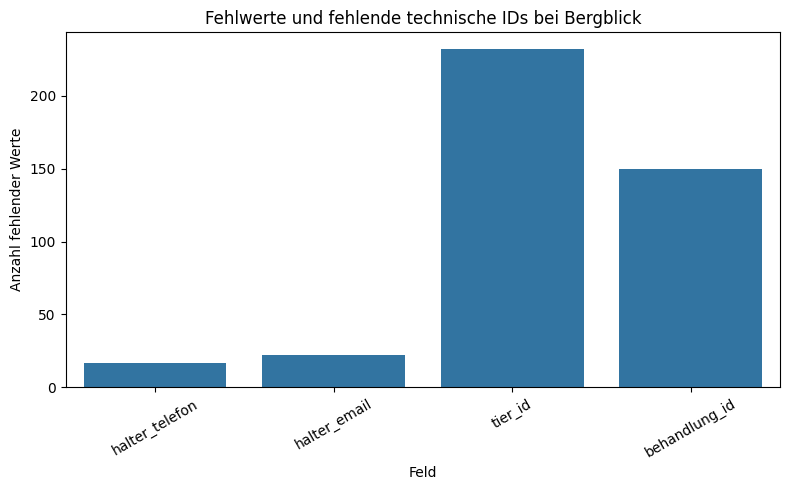

,Feld,Fehlende Werte
0,halter_telefon,17
1,halter_email,22
2,tier_id,232
3,behandlung_id,150


In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

missing_berg_focus = pd.DataFrame({
    "Feld": ["halter_telefon", "halter_email", "tier_id", "behandlung_id"],
    "Fehlende Werte": [
        df_berg_p["halter_telefon"].isna().sum() if "halter_telefon" in df_berg_p.columns else 0,
        df_berg_p["halter_email"].isna().sum() if "halter_email" in df_berg_p.columns else 0,
        df_berg_p["tier_id"].isna().sum() if "tier_id" in df_berg_p.columns else 0,
        df_berg_b["behandlung_id"].isna().sum() if "behandlung_id" in df_berg_b.columns else 0,
    ]
})

plt.figure(figsize=(8, 5))
sns.barplot(
    data=missing_berg_focus,
    x="Feld",
    y="Fehlende Werte"
)

plt.title("Fehlwerte und fehlende technische IDs bei Bergblick")
plt.xlabel("Feld")
plt.ylabel("Anzahl fehlender Werte")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

display(missing_berg_focus)

**Interpretation**

Die wichtigsten Ergebnisse für Bergblick sind:

- Es gibt **232 Patienten/Halter/Tier-Datensätze** und **150 Behandlungen**.
- Es gibt **keine fehlenden Patient-IDs** in den Patienten-Daten.
- Es gibt **keine Behandlungen ohne Patient-ID**.
- Es gibt **0 verwaiste Behandlungsreferenzen**. Das bedeutet: Jede Behandlung verweist auf eine vorhandene `patient_id`.
- Die Behandlungsdaten haben **0 fehlende Datumswerte**.
- `kosten_netto` und `kosten_brutto` sind numerisch interpretierbar.
- Es gibt **0 Fälle**, in denen Brutto kleiner als Netto ist.
- Tierarten sind sauber verteilt: **121 Katze**, **111 Hund**.
- Auffällig sind fehlende Kontaktinformationen: **17 Telefonnummern** und **22 E-Mail-Adressen** fehlen.
- Die Quelle liefert keine separate `tier_id` und keine eigene `behandlung_id`; dafür muss in der Pipeline eine technische ID bzw. `xml_position` verwendet werden.

Bergblick ist insgesamt für die Pipeline fachlich gut nutzbar.


### 9.6 Bergblick-spezifische Auffälligkeiten



Initialen statt vollständiger Vornamen

In [66]:
# Initialen statt ausgeschriebener Vornamen prüfen
if "halter_vorname" in df_berg_p.columns:
    initial_mask = (
        df_berg_p["halter_vorname"]
        .dropna()
        .astype(str)
        .str.match(r"^[A-ZÄÖÜ]\.$")
    )

    initial_count = initial_mask.sum()

    print("Anzahl Vornamen nur als Initiale:", initial_count)

    display(
        df_berg_p[
            df_berg_p["halter_vorname"].astype(str).str.match(r"^[A-ZÄÖÜ]\.$", na=False)
        ][["halter_name", "halter_vorname", "halter_nachname"]].head(10)
    )

Anzahl Vornamen nur als Initiale: 8


,halter_name,halter_vorname,halter_nachname
3,B. Schulz,B.,Schulz
205,F. Lehmann,F.,Lehmann
206,E. Kaiser,E.,Kaiser
209,K. Kaiser,K.,Kaiser
213,N. Lehmann,N.,Lehmann
215,O. Braun,O.,Braun
219,S. Hoffmann,S.,Hoffmann
228,X. Neumann,X.,Neumann


Einige Halternamen enthalten nur Initialen statt ausgeschriebener Vornamen. Für das spätere Matching ist das relevant, weil eine Initiale weniger eindeutig ist als ein vollständiger Vorname. Solche Datensätze sollten daher nicht nur über den Namen, sondern zusätzlich über Adresse, Telefonnummer oder E-Mail abgeglichen werden.

XML-Attribute statt Kindelemente

In [67]:
xml_attribute_info = pd.DataFrame([
    {
        "bereich": "patient",
        "attribut": "id",
        "bedeutung": "technische Patient-ID"
    },
    {
        "bereich": "behandlung",
        "attribut": "patientId",
        "bedeutung": "Referenz auf Patient"
    },
    {
        "bereich": "behandlung",
        "attribut": "datum",
        "bedeutung": "Behandlungsdatum"
    },
    {
        "bereich": "summe",
        "attribut": "netto",
        "bedeutung": "Nettobetrag"
    },
    {
        "bereich": "summe",
        "attribut": "brutto",
        "bedeutung": "Bruttobetrag"
    }
])

display(xml_attribute_info)

,bereich,attribut,bedeutung
0,patient,id,technische Patient-ID
1,behandlung,patientId,Referenz auf Patient
2,behandlung,datum,Behandlungsdatum
3,summe,netto,Nettobetrag
4,summe,brutto,Bruttobetrag



Bei Bergblick liegen mehrere zentrale Informationen nicht als normale XML-Kindelemente, sondern als Attribute vor. Besonders relevant sind `patientId`, `datum`, `netto` und `brutto`. Ein Parser, der nur Kindelemente ausliest, würde diese Werte verlieren. Deshalb ist für Bergblick ein spezielles XML-Flattening notwendig.

Netto-/Brutto-Verhältnis

In [68]:
df_berg_b["kosten_netto_num"] = parse_amount_series(df_berg_b["kosten_netto"])
df_berg_b["kosten_brutto_num"] = parse_amount_series(df_berg_b["kosten_brutto"])

df_berg_b["steuer_faktor"] = df_berg_b["kosten_brutto_num"] / df_berg_b["kosten_netto_num"]

print("Durchschnittlicher Brutto/Netto-Faktor:")
print(round(df_berg_b["steuer_faktor"].mean(), 3))

display(
    df_berg_b[["kosten_netto", "kosten_brutto", "steuer_faktor"]]
    .sort_values("steuer_faktor")
    .head(10)
)

Durchschnittlicher Brutto/Netto-Faktor:
1.19


,kosten_netto,kosten_brutto,steuer_faktor
37,20.97,24.95,1.189795
139,37.61,44.75,1.189843
16,30.55,36.35,1.189853
134,24.65,29.33,1.189858
1,32.55,38.73,1.189862
97,38.92,46.31,1.189877
143,31.02,36.91,1.189877
61,16.80,19.99,1.189881
40,33.02,39.29,1.189885
48,51.45,61.22,1.189893


Bergblick unterscheidet zwischen Netto- und Bruttobeträgen. Dadurch muss im Transformationsschritt entschieden werden, welcher Betrag in das Zielmodell übernommen wird. Zusätzlich kann geprüft werden, ob der Bruttobetrag plausibel größer als der Nettobetrag ist. Diese Prüfung hilft, semantische Fehler in Kostenfeldern zu erkennen.

###9.7 Zusammenfassung der Ergebnisse
Jetzt wird eine kompakte Übersicht erstellt.


In [69]:
berg_summary = {
    "patienten_zeilen": len(df_berg_p),
    "patienten_spalten": len(df_berg_p.columns),
    "behandlungen_zeilen": len(df_berg_b),
    "behandlungen_spalten": len(df_berg_b.columns),
    "namespace": ns_uri,
    "anzahl_dq_checks": len(df_berg_checks),
    "anzahl_orphan_refs": len(orphan_refs),
    "fehlende_telefone": int(df_berg_p["halter_telefon"].isna().sum()) if "halter_telefon" in df_berg_p.columns else None,
    "fehlende_emails": int(df_berg_p["halter_email"].isna().sum()) if "halter_email" in df_berg_p.columns else None,
}

display(pd.DataFrame([berg_summary]))

,patienten_zeilen,patienten_spalten,behandlungen_zeilen,behandlungen_spalten,namespace,anzahl_dq_checks,anzahl_orphan_refs,fehlende_telefone,fehlende_emails
0,232,18,150,11,http://vetkliniken-hessen.de/schema/v2,25,0,17,22



Die Zusammenfassung zeigt kompakt, dass Bergblick eine technisch komplexe, aber gut verwertbare Quelle ist. Besonders wichtig:
- Die XML-Quelle enthält mehr Struktur als die anderen Quellen.
- Das Flattening erzeugt zwei nutzbare Tabellen.
- Referenzen zwischen Patienten und Behandlungen sind konsistent.
- Kontaktfelder sind teilweise unvollständig und können das spätere Matching schwächen.
- Für fehlende technische IDs müssen eigene technische Schlüssel bzw. Provenance-Spalten genutzt werden.

Dies muss beim Aufbau der Pipeline beachtet werden.


### 9.8 Markdown-Reports erzeugen

Diese Zelle schreibt die zwei Dateien:

- `docs/w7_profiling/berg_patienten.md`
- `docs/w7_profiling/berg_behandlungen.md`

Die Reports enthalten Dateiinformationen, Spaltenprofile, auffällige Muster, Datenqualitätsprobleme und eine kurze Bewertung für die Pipeline.


In [70]:
berg_patienten_probleme = df_berg_checks[
    df_berg_checks["quelle"].isin(["berg_patienten", "berg_export"])
].copy()

berg_behandlungen_probleme = df_berg_checks[
    df_berg_checks["quelle"].isin(["berg_behandlungen", "berg_export"])
].copy()

tierarten_md = (
    tierarten.to_markdown(index=False)
    if not tierarten.empty else "_Keine Tierart-Spalte gefunden._"
)

report_berg_p = f"""# Profiling: praxis_bergblick_export.xml – Patienten/Halter/Tiere

_Erstellt: {datetime.today().strftime('%Y-%m-%d')}_

## Datei
- Format: XML
- Namespace: `{ns_uri if ns_uri else 'kein Namespace erkannt'}`
- Encoding: UTF-8
- Header: nein, XML-Struktur
- Zeilen Patienten/Halter/Tiere: {len(df_berg_p)}
- Spalten nach Flattening: {len(df_berg_p.columns)}

## Fachliche Einordnung
Die Bergblick-Quelle unterscheidet sich deutlich von den CSV- und JSON-Quellen, da Halter- und Tierinformationen gemeinsam in verschachtelten XML-Elementen gespeichert sind. Für die weitere Verarbeitung müssen diese Informationen zuerst in eine tabellarische Form überführt werden.

## Spalten

{df_to_column_table(df_berg_p)}

## Ergebnisinterpretation
Das Profiling zeigt, dass die wesentlichen fachlichen Informationen für Halter und Tiere vorhanden sind. Patient-ID, Name, Adresse, Tiername, Tierart und Tiergeburtsdatum sind vollständig. Auffällig sind fehlende Kontaktinformationen: Telefonnummern fehlen bei {int(df_berg_p['halter_telefon'].isna().sum()) if 'halter_telefon' in df_berg_p.columns else 'n/a'} Datensätzen und E-Mail-Adressen bei {int(df_berg_p['halter_email'].isna().sum()) if 'halter_email' in df_berg_p.columns else 'n/a'} Datensätzen. Das ist besonders relevant für das spätere Matching, da Telefon und E-Mail starke Identifikatoren für Dublettenerkennung sind.

## Auffällige Muster
- XML-Datei verwendet einen Namespace; XPath-Abfragen müssen den Namespace berücksichtigen.
- Halter- und Tierdaten liegen verschachtelt innerhalb eines `patient`-Elements.
- Kontakt- und Adressdaten liegen in Unterelementen wie `kontakt` und `adresse`.
- Für Staging und Transform ist ein explizites Flattening notwendig.
- Die Patient-ID ist das zentrale Referenzmerkmal für spätere Behandlungen.
- Eine separate Tier-ID ist nicht vorhanden; Tierinformationen müssen über Patient-ID und Tierattribute zugeordnet werden.

## Tierarten

{tierarten_md}

## Datenqualitätsprobleme

{berg_patienten_probleme.to_markdown(index=False)}

## Bewertung für die Pipeline
Die Quelle ist fachlich gut nutzbar, erfordert aber einen XML-spezifischen Parser. Besonders wichtig sind Namespace-Handling, Flattening der Halter-/Tierstruktur und der Erhalt der Patient-ID als Provenance- und Referenzmerkmal. Fehlende Kontaktinformationen müssen später im Matching berücksichtigt werden, weil dadurch E-Mail- oder Telefon-Matches nicht für alle Datensätze möglich sind.
"""

report_berg_b = f"""# Profiling: praxis_bergblick_export.xml – Behandlungen

_Erstellt: {datetime.today().strftime('%Y-%m-%d')}_

## Datei
- Format: XML, gleiche Quelldatei wie Patienten/Halter/Tiere
- Namespace: `{ns_uri if ns_uri else 'kein Namespace erkannt'}`
- Encoding: UTF-8
- Header: nein, XML-Struktur
- Zeilen Behandlungen: {len(df_berg_b)}
- Spalten nach Flattening: {len(df_berg_b.columns)}

## Fachliche Einordnung
Die Behandlungen aus Bergblick sind separat innerhalb der XML-Datei gespeichert. Sie referenzieren Patienten über `patientId`. Das Datum liegt als Attribut vor. Die Kosten sind als Netto- und Bruttobetrag getrennt gespeichert.

## Spalten

{df_to_column_table(df_berg_b)}

## Ergebnisinterpretation
Das Profiling zeigt, dass die zentralen Behandlungsinformationen vollständig extrahiert werden konnten. `patient_id`, `datum`, `diagnose`, `kosten_netto` und `kosten_brutto` sind vorhanden. Es gibt keine verwaisten Behandlungsreferenzen, d. h. jede Behandlung verweist auf eine vorhandene Patient-ID. Die Beträge sind numerisch interpretierbar und die Brutto-/Netto-Logik ist plausibel.

Auffällig ist, dass keine explizite Behandlungs-ID vorliegt. Für die Pipeline sollte deshalb eine technische ID oder die XML-Position als Provenance-Merkmal genutzt werden.

## Auffällige Muster
- `patientId` liegt als Attribut der Behandlung vor.
- `datum` liegt ebenfalls als Attribut vor.
- Die Behandlungssumme ist in Netto- und Bruttobetrag aufgeteilt.
- Netto und Brutto liegen als Attribute des `summe`-Elements vor.
- Eine naive Element-Extraktion würde diese Werte verlieren und später künstliche Rejects erzeugen.
- Keine explizite Behandlungs-ID vorhanden; technische ID aus `xml_position` sinnvoll.

## Datenqualitätsprobleme

{berg_behandlungen_probleme.to_markdown(index=False)}

## Bewertung für die Pipeline
Für Bergblick ist besonders wichtig, dass der XML-Parser sowohl Elemente als auch Attribute ausliest. Andernfalls würden Patient-Referenzen, Behandlungsdatum und Kostenbeträge fehlen. Das würde in der Transform-Schicht fälschlich als Datenqualitätsproblem erscheinen. Inhaltlich sind die Behandlungsdaten stabil; technisch muss jedoch eine eigene technische ID erzeugt werden.
"""

write_report("berg_patienten.md", report_berg_p)
write_report("berg_behandlungen.md", report_berg_b)

print("\nKontrolle Fehlwerte Patienten:")
display(df_berg_p.isna().sum().reset_index().rename(columns={"index": "spalte", 0: "fehlwerte"}))

print("\nKontrolle Fehlwerte Behandlungen:")
display(df_berg_b.isna().sum().reset_index().rename(columns={"index": "spalte", 0: "fehlwerte"}))

✓ Report geschrieben: docs/w7_profiling/berg_patienten.md
✓ Report geschrieben: docs/w7_profiling/berg_behandlungen.md

Kontrolle Fehlwerte Patienten:


,spalte,fehlwerte
0,xml_position,0
1,patient_id,0
2,patient_quell_id,0
3,halter_id,0
4,halter_anrede,0
5,halter_name,0
6,halter_vorname,0
7,halter_nachname,0
8,halter_telefon,17
9,halter_telefon_typ,17



Kontrolle Fehlwerte Behandlungen:


,spalte,fehlwerte
0,xml_position,0
1,behandlung_id,150
2,patient_id,0
3,datum,0
4,diagnose,0
5,leistung,150
6,kosten_netto,0
7,kosten_brutto,0
8,kosten_netto_num,0
9,kosten_brutto_num,0


### 9.9 Bergblick-Einträge für die gemeinsame Fehlerliste vorbereiten

Die Bergblick-spezifische Einträge zur `fehlerliste.md` werden erstellt.  
Dabei werden Fehlwerte dokumentiert, aber auch strukturelle Risiken wie XML-Namespace, Attribute und fehlende technische IDs.


In [71]:
berg_fehler = [
    (
        "Schema/Struktur",
        "berg_patienten",
        "XML-Struktur",
        "Halter- und Tierdaten sind verschachtelt in einem patient-Element gespeichert und müssen vor der Transformation geflattet werden."
    ),
    (
        "Encoding/Parser",
        "berg_export",
        "Namespace",
        "XML verwendet einen Namespace; Parser/XPath-Abfragen müssen namespace-aware umgesetzt werden."
    ),
    (
        "Format/Parser",
        "berg_behandlungen",
        "patientId/datum",
        "Patientenreferenz und Behandlungsdatum liegen als XML-Attribute vor, nicht als normale Kind-Elemente."
    ),
    (
        "Semantik",
        "berg_behandlungen",
        "kosten_netto/kosten_brutto",
        "Behandlungskosten sind als Netto- und Bruttobetrag getrennt gespeichert; für das Zielmodell muss eine Auswahlregel definiert werden."
    ),
    (
        "Referenz",
        "berg_behandlungen",
        "patient_id",
        f"{len(orphan_refs)} Behandlungsreferenzen zeigen auf keine vorhandene Patient-ID."
    ),
    (
        "Fehlwerte",
        "berg_patienten",
        "halter_telefon",
        f"{int(df_berg_p['halter_telefon'].isna().sum()) if 'halter_telefon' in df_berg_p.columns else 'n/a'} Telefonnummern fehlen; dadurch ist Telefon-Matching nicht für alle Datensätze möglich."
    ),
    (
        "Fehlwerte",
        "berg_patienten",
        "halter_email",
        f"{int(df_berg_p['halter_email'].isna().sum()) if 'halter_email' in df_berg_p.columns else 'n/a'} E-Mail-Adressen fehlen; dadurch ist E-Mail-Matching nicht für alle Datensätze möglich."
    ),
    (
        "Schema/Struktur",
        "berg_behandlungen",
        "behandlung_id",
        "Keine explizite Behandlungs-ID vorhanden; eine technische ID bzw. xml_position sollte als Provenance-Merkmal genutzt werden."
    ),
]

print("Bergblick-Einträge für fehlerliste.md:")
for eintrag in berg_fehler:
    print(eintrag)

Bergblick-Einträge für fehlerliste.md:
('Schema/Struktur', 'berg_patienten', 'XML-Struktur', 'Halter- und Tierdaten sind verschachtelt in einem patient-Element gespeichert und müssen vor der Transformation geflattet werden.')
('Encoding/Parser', 'berg_export', 'Namespace', 'XML verwendet einen Namespace; Parser/XPath-Abfragen müssen namespace-aware umgesetzt werden.')
('Format/Parser', 'berg_behandlungen', 'patientId/datum', 'Patientenreferenz und Behandlungsdatum liegen als XML-Attribute vor, nicht als normale Kind-Elemente.')
('Semantik', 'berg_behandlungen', 'kosten_netto/kosten_brutto', 'Behandlungskosten sind als Netto- und Bruttobetrag getrennt gespeichert; für das Zielmodell muss eine Auswahlregel definiert werden.')
('Referenz', 'berg_behandlungen', 'patient_id', '0 Behandlungsreferenzen zeigen auf keine vorhandene Patient-ID.')
('Fehlwerte', 'berg_patienten', 'halter_telefon', '17 Telefonnummern fehlen; dadurch ist Telefon-Matching nicht für alle Datensätze möglich.')
('Fehlwe

**Ergebnis und Interpretation**

Nun sichtbar in der gemeinsamen Fehlerliste (auch Unterscheidung zwischen echten Datenqualitätsproblemen und strukturellen Besonderheiten):

- Echte Datenqualitätsprobleme: fehlende Telefonnummern und E-Mails.
- Strukturprobleme: XML-Verschachtelung, Namespace, Attribute, fehlende technische Behandlungs-ID.
- Positive Erkenntnis: Die Referenzen zwischen Behandlungen und Patienten sind konsistent.


# 10 · Data Dictionary (alle Quellen zusammengeführt)

In [72]:
import pandas as pd
from pathlib import Path
from datetime import datetime

OUT_DIR = Path("/content/docs/w7_profiling")
OUT_DIR.mkdir(parents=True, exist_ok=True)

sources = {
    "Juckstadt Kunden": df_juck_k,
    "Juckstadt Behandlungen": df_juck_b,
    "Waldrand Kunden": df_wald_k,
    "Waldrand Behandlungen": df_wald_b,
    "Schmidt Kunden": df_k,
    "Schmidt Behandlungen": df_b,
    "Bergblick Patienten": df_berg_p,
    "Bergblick Behandlungen": df_berg_b,
}

dd_rows = []

for source_name, df in sources.items():
    for col in df.columns:
        dd_rows.append({
            "Quelle": source_name,
            "Spalte": col,
            "Datentyp": str(df[col].dtype),
            "Beispielwert": df[col].dropna().astype(str).head(1).iloc[0] if df[col].notna().any() else "",
            "Anzahl Werte": int(df[col].count()),
            "Fehlwerte": int(df[col].isna().sum()),
            "Fehlwerte %": round(df[col].isna().mean() * 100, 2),
            "Eindeutige Werte": int(df[col].nunique(dropna=True))
        })

data_dictionary = pd.DataFrame(dd_rows)

data_dictionary_md = f"""# Data Dictionary

Erstellt am: {datetime.today().strftime('%Y-%m-%d')}

## Quellen x Spalten zusammengeführt

{data_dictionary.to_markdown(index=False)}
"""

data_dictionary_path = OUT_DIR / "data_dictionary.md"
data_dictionary_path.write_text(data_dictionary_md, encoding="utf-8")

display(data_dictionary)

print(f"Markdown-Datei gespeichert: {data_dictionary_path}")



,Quelle,Spalte,Datentyp,Beispielwert,Anzahl Werte,Fehlwerte,Fehlwerte %,Eindeutige Werte
0,Juckstadt Kunden,kunden_nr,object,1,223,0,0.0,223
1,Juckstadt Kunden,anrede,object,Herr,223,0,0.0,2
2,Juckstadt Kunden,vorname,object,Thomas,223,0,0.0,63
3,Juckstadt Kunden,nachname,object,Berger,223,0,0.0,43
4,Juckstadt Kunden,strasse,object,Hauptstr. 12,223,0,0.0,214
...,...,...,...,...,...,...,...,...
79,Bergblick Behandlungen,kosten_netto,object,162.92,150,0,0.0,150
80,Bergblick Behandlungen,kosten_brutto,object,193.87,150,0,0.0,150
81,Bergblick Behandlungen,kosten_netto_num,float64,162.92,150,0,0.0,150
82,Bergblick Behandlungen,kosten_brutto_num,float64,193.87,150,0,0.0,150


Markdown-Datei gespeichert: /content/docs/w7_profiling/data_dictionary.md


# 11 · Fehlerliste (≥ 10 konkrete DQ-Probleme)

In [73]:
# ------------------------------------------------------------------
# 11. Fehlerliste
# ------------------------------------------------------------------

from pathlib import Path
from datetime import datetime
import pandas as pd

OUT_DIR = Path("/content/docs/w7_profiling")
OUT_DIR.mkdir(parents=True, exist_ok=True)

fehler = []

def add_fehler(praxis, quelle, kategorie, feld, problem, begruendung, prioritaet):
    fehler.append({
        "Praxis": praxis,
        "Quelle": quelle,
        "Kategorie": kategorie,
        "Feld": feld,
        "Problem": problem,
        "Begründung": begruendung,
        "Priorität": prioritaet
    })

# ----------------------------------------------------------
# Konkrete DQ-Probleme über alle Praxen
# ----------------------------------------------------------

add_fehler(
    "Juckstadt",
    "praxis_juckstadt_kunden.csv",
    "Fehlwerte",
    "email / telefon",
    "Kontaktinformationen teilweise leer",
    "Fehlende Kontaktfelder erschweren Kundenkommunikation und Dublettenprüfung.",
    "Mittel"
)

add_fehler(
    "Juckstadt",
    "praxis_juckstadt_kunden.csv",
    "Format",
    "plz",
    "Postleitzahlen müssen als String behandelt werden",
    "PLZ darf nicht numerisch verarbeitet werden, da führende Nullen verloren gehen können.",
    "Hoch"
)

add_fehler(
    "Juckstadt",
    "praxis_juckstadt_behandlungen.csv",
    "Semantik",
    "kosten_euro",
    "Betrag ist fachlich Brutto/Netto nicht eindeutig",
    "Ohne klare Semantik ist die spätere Abrechnungsauswertung unsicher.",
    "Hoch"
)

add_fehler(
    "Waldrand",
    "praxis_waldrand.json",
    "Schema-Drift",
    "customer_id / treatment_id",
    "Andere Feldnamen als in Juckstadt",
    "Gleiche fachliche Konzepte werden mit anderen Spaltennamen geliefert.",
    "Hoch"
)

add_fehler(
    "Waldrand",
    "praxis_waldrand.json",
    "Format",
    "JSON-Struktur",
    "Verschachtelte Struktur muss geflattet werden",
    "Für ein gemeinsames Zielmodell müssen verschachtelte Objekte in Tabellenform gebracht werden.",
    "Hoch"
)

add_fehler(
    "Waldrand",
    "praxis_waldrand.json",
    "Semantik",
    "total_eur",
    "Betrag ist nicht eindeutig als Netto oder Brutto beschrieben",
    "Die Bedeutung des Betrags muss vor der Integration geklärt werden.",
    "Mittel"
)

add_fehler(
    "Schmidt",
    "praxis_schmidt.xml",
    "Schema-Drift",
    "kunden_id",
    "Keine stabile Kunden-ID vorhanden",
    "Kunden können nicht zuverlässig über eine technische ID zusammengeführt werden.",
    "Hoch"
)

add_fehler(
    "Schmidt",
    "praxis_schmidt.xml",
    "Format",
    "XML-Struktur",
    "XML muss vor Analyse und Mapping normalisiert werden",
    "Die Daten liegen nicht direkt tabellarisch vor.",
    "Hoch"
)

add_fehler(
    "Schmidt",
    "praxis_schmidt.xml",
    "Encoding",
    "Textfelder",
    "Sonderzeichen und Umlaute müssen geprüft werden",
    "Bei XML-Importen können Encoding-Probleme in Namen, Diagnosen oder Ortsangaben auftreten.",
    "Mittel"
)

add_fehler(
    "Bergblick",
    "praxis_bergblick.csv",
    "Dubletten",
    "halter_id / tier_name / datum",
    "Mögliche Mehrfacherfassungen gleicher Behandlungen",
    "Kombinationen aus Halter, Tier und Datum sollten auf Dubletten geprüft werden.",
    "Hoch"
)

add_fehler(
    "Bergblick",
    "praxis_bergblick.csv",
    "Schema-Drift",
    "kosten_netto / kosten_brutto",
    "Bergblick trennt Netto und Brutto, andere Praxen nicht",
    "Das Zielmodell muss Betragsfelder vereinheitlichen.",
    "Hoch"
)

add_fehler(
    "Alle Praxen",
    "alle Quellen",
    "Semantik",
    "tier_name / patient_name / animal_name",
    "Tiername ist keine eindeutige Tier-ID",
    "Mehrere Tiere können gleich heißen; Tiernamen dürfen nicht als Schlüssel verwendet werden.",
    "Hoch"
)

# ----------------------------------------------------------
# Fehlerliste als DataFrame und Markdown speichern
# ----------------------------------------------------------

fehlerliste = pd.DataFrame(fehler)

fehlerliste_md = f"""# Fehlerliste

Erstellt am: {datetime.today().strftime('%Y-%m-%d')}

## Datenqualitätsprobleme

Die Fehlerliste enthält konkret benannte Datenqualitätsprobleme über alle analysierten Praxen.

Kategorien:
Schema-Drift, Format, Encoding, Fehlwerte, Dubletten, Semantik

{fehlerliste.to_markdown(index=False)}
"""

fehlerliste_path = OUT_DIR / "fehlerliste.md"
fehlerliste_path.write_text(fehlerliste_md, encoding="utf-8")

display(fehlerliste)

print(f"Markdown-Datei gespeichert: {fehlerliste_path}")

,Praxis,Quelle,Kategorie,Feld,Problem,Begründung,Priorität
0,Juckstadt,praxis_juckstadt_kunden.csv,Fehlwerte,email / telefon,Kontaktinformationen teilweise leer,Fehlende Kontaktfelder erschweren Kundenkommun...,Mittel
1,Juckstadt,praxis_juckstadt_kunden.csv,Format,plz,Postleitzahlen müssen als String behandelt werden,"PLZ darf nicht numerisch verarbeitet werden, d...",Hoch
2,Juckstadt,praxis_juckstadt_behandlungen.csv,Semantik,kosten_euro,Betrag ist fachlich Brutto/Netto nicht eindeutig,Ohne klare Semantik ist die spätere Abrechnung...,Hoch
3,Waldrand,praxis_waldrand.json,Schema-Drift,customer_id / treatment_id,Andere Feldnamen als in Juckstadt,Gleiche fachliche Konzepte werden mit anderen ...,Hoch
4,Waldrand,praxis_waldrand.json,Format,JSON-Struktur,Verschachtelte Struktur muss geflattet werden,Für ein gemeinsames Zielmodell müssen verschac...,Hoch
5,Waldrand,praxis_waldrand.json,Semantik,total_eur,Betrag ist nicht eindeutig als Netto oder Brut...,Die Bedeutung des Betrags muss vor der Integra...,Mittel
6,Schmidt,praxis_schmidt.xml,Schema-Drift,kunden_id,Keine stabile Kunden-ID vorhanden,Kunden können nicht zuverlässig über eine tech...,Hoch
7,Schmidt,praxis_schmidt.xml,Format,XML-Struktur,XML muss vor Analyse und Mapping normalisiert ...,Die Daten liegen nicht direkt tabellarisch vor.,Hoch
8,Schmidt,praxis_schmidt.xml,Encoding,Textfelder,Sonderzeichen und Umlaute müssen geprüft werden,Bei XML-Importen können Encoding-Probleme in N...,Mittel
9,Bergblick,praxis_bergblick.csv,Dubletten,halter_id / tier_name / datum,Mögliche Mehrfacherfassungen gleicher Behandlu...,"Kombinationen aus Halter, Tier und Datum sollt...",Hoch


Markdown-Datei gespeichert: /content/docs/w7_profiling/fehlerliste.md
